# Practical Assignment: Classifiers
## Comparing KNN, SVM and MLP on the scikit-learn *Digits* dataset

**Tomás Ferreira** 2025168427

## 1. Introduction and Objective

- Goal: build, train and compare **KNN**, **SVM** and **MLP** classifiers with scikit-learn.
- Order: Iris example → Digits EDA → KNN / SVM / MLP → comparison → conclusions.
- Extra work (section 13): MNIST, KNN scalability and a CNN.

**Protocol (same for every model)**
- Train (60 %): model fitting.
- Validation (20 %): hyperparameter selection.
- Test (20 %): final evaluation only, once per final model.
- Final models are retrained on train + validation.

## 2. Imports and Global Configuration

### 2.1 Import libraries

In [1]:
import hashlib
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.datasets import load_digits, load_iris
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 4)
pd.set_option("display.max_colwidth", 120)

print("scikit-learn:", sklearn.__version__, "| numpy:", np.__version__, "| pandas:", pd.__version__)

scikit-learn: 1.9.1 | numpy: 2.5.3 | pandas: 3.0.6


### 2.2 Global configuration

- `RANDOM_STATE = 42` for every split and estimator.
- Trained models are saved in `checkpoints/` and reused when data and parameters match.
- `FORCE_RETRAIN = True` retrains everything.

In [2]:
RANDOM_STATE = 42
FORCE_RETRAIN = False

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

## 3. First Step — Iris

- Minimal scikit-learn workflow: split → fit → predict → accuracy.
- No tuning, so a simple train/test split is enough.

In [3]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

print("Features:", iris.feature_names)
print("Classes :", list(iris.target_names))
print("X shape :", X_iris.shape, "| y shape:", y_iris.shape)

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_iris, y_iris, test_size=0.25, random_state=RANDOM_STATE, stratify=y_iris
)

iris_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5)),
])
iris_model.fit(Xi_train, yi_train)
yi_pred = iris_model.predict(Xi_test)

print(f"\nIris test accuracy (KNN, k=5): {accuracy_score(yi_test, yi_pred):.4f}")
print("First 10 predictions:", iris.target_names[yi_pred[:10]])
print("First 10 true labels:", iris.target_names[yi_test[:10]])

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
X shape : (150, 4) | y shape: (150,)

Iris test accuracy (KNN, k=5): 0.9211
First 10 predictions: ['setosa' 'versicolor' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'virginica' 'virginica']
First 10 true labels: ['setosa' 'versicolor' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'virginica' 'virginica' 'virginica' 'virginica']


- 35 of 38 test flowers correct (accuracy ≈ 0.92).
- Errors occur between *versicolor* and *virginica*.

## 4. The Digits Dataset

### 4.1 Load the dataset

In [4]:
digits = load_digits()

print("Object type :", type(digits))
print("Keys        :", list(digits.keys()))

Object type : <class 'sklearn.utils._bunch.Bunch'>
Keys        : ['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR']


### 4.2 Dataset overview

In [5]:
n_samples, n_features = digits.data.shape

overview = pd.Series({
    "digits.data shape": digits.data.shape,
    "digits.data dtype": digits.data.dtype,
    "digits.target shape": digits.target.shape,
    "digits.target dtype": digits.target.dtype,
    "digits.images shape": digits.images.shape,
    "number of samples": n_samples,
    "number of features": n_features,
    "image dimensions": digits.images.shape[1:],
    "number of classes": len(digits.target_names),
    "class values (target_names)": list(digits.target_names),
}, name="value")
overview.to_frame()

,value
digits.data shape,"(1797, 64)"
digits.data dtype,float64
digits.target shape,"(1797,)"
digits.target dtype,int64
digits.images shape,"(1797, 8, 8)"
number of samples,1797
number of features,64
image dimensions,"(8, 8)"
number of classes,10
class values (target_names),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"


In [ ]:
print("\n".join(digits.DESCR.splitlines()[:22]))

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a


### 4.3 First look at the observations

- `digits.data`: 64 pixel values per image; `digits.images`: the same values as 8×8 arrays; `digits.target`: digit 0–9.

In [7]:
digits_df = pd.DataFrame(digits.data, columns=digits.feature_names)
digits_df["target"] = digits.target
digits_df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [8]:
print("digits.images[0] (8x8 matrix), label =", digits.target[0])
print(digits.images[0].astype(int))

same_values = np.array_equal(digits.data, digits.images.reshape(n_samples, -1))
print("\ndigits.data == digits.images flattened (all samples):", same_values)

digits.images[0] (8x8 matrix), label = 0
[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]

digits.data == digits.images flattened (all samples): True


## 5. Exploratory Data Analysis

- Descriptive only: no statistic computed here is used to transform the data.

### 5.1 Data integrity: missing values, infinities, shapes and value ranges

In [9]:
X_all, y_all = digits.data, digits.target

integrity = pd.Series({
    "X shape": X_all.shape,
    "y shape": y_all.shape,
    "X and y have the same number of rows": X_all.shape[0] == y_all.shape[0],
    "NaN values in X": int(np.isnan(X_all).sum()),
    "NaN values in y": int(pd.isna(y_all).sum()),
    "infinite values in X": int(np.isinf(X_all).sum()),
    "min pixel value": X_all.min(),
    "max pixel value": X_all.max(),
    "all pixel values are integers": bool(np.all(X_all == np.round(X_all))),
    "distinct pixel values": np.unique(X_all).size,
    "distinct labels": np.unique(y_all).tolist(),
}, name="result")
integrity.to_frame()

,result
X shape,"(1797, 64)"
y shape,"(1797,)"
X and y have the same number of rows,True
NaN values in X,0
NaN values in y,0
infinite values in X,0
min pixel value,0.0
max pixel value,16.0
all pixel values are integers,True
distinct pixel values,17


In [ ]:
missing_per_column = digits_df.isna().sum()
print("Columns with missing values:", missing_per_column[missing_per_column > 0].to_dict())
print("Total missing values in the DataFrame:", int(missing_per_column.sum()))

Columns with missing values: {}
Total missing values in the DataFrame: 0


### 5.2 Duplicate observations

- Duplicates could leak between subsets; conflicting labels would indicate label noise.

In [11]:
pixel_cols = list(digits.feature_names)

n_duplicated_rows = int(digits_df.duplicated(subset=pixel_cols).sum())
labels_per_image = digits_df.groupby(pixel_cols)["target"].nunique()
n_conflicting = int((labels_per_image > 1).sum())

print("Duplicated images (same 64 pixels)          :", n_duplicated_rows)
print("Identical images with conflicting labels    :", n_conflicting)

Duplicated images (same 64 pixels)          : 0
Identical images with conflicting labels    : 0


### 5.3 Label analysis — class distribution

In [12]:
class_counts = pd.Series(y_all).value_counts().sort_index()
class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage (%)": 100 * class_counts / len(y_all),
})
class_distribution.index.name = "digit"
print(class_distribution.T.round(2).to_string())

print(f"\nSmallest class: digit {class_counts.idxmin()} ({class_counts.min()} samples)")
print(f"Largest class : digit {class_counts.idxmax()} ({class_counts.max()} samples)")
print(f"Imbalance ratio (largest / smallest): {class_counts.max() / class_counts.min():.3f}")

digit                0       1       2       3       4       5       6       7       8       9
count           178.00  182.00  177.00  183.00  181.00  182.00  181.00  179.00  174.00  180.00
percentage (%)    9.91   10.13    9.85   10.18   10.07   10.13   10.07    9.96    9.68   10.02

Smallest class: digit 8 (174 samples)
Largest class : digit 3 (183 samples)
Imbalance ratio (largest / smallest): 1.052


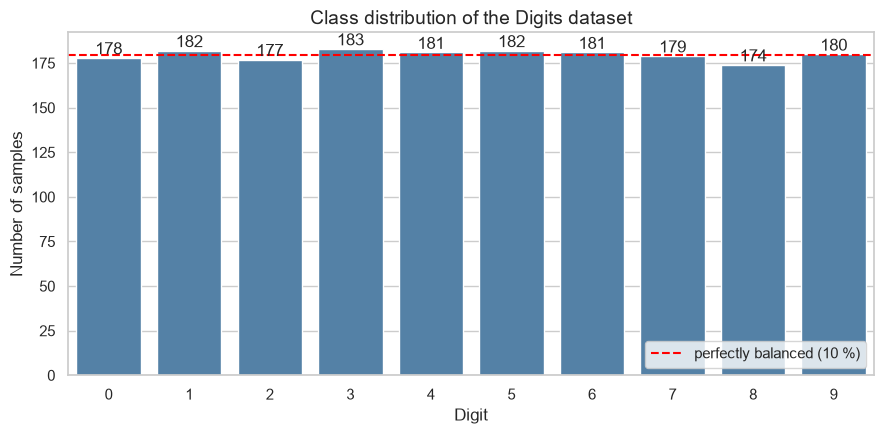

In [13]:
plt.figure(figsize=(9, 4.5))
ax = sns.countplot(x=y_all, color="steelblue")
ax.axhline(len(y_all) / 10, color="red", linestyle="--", label="perfectly balanced (10 %)")
ax.bar_label(ax.containers[0])
ax.set_xlabel("Digit")
ax.set_ylabel("Number of samples")
ax.set_title("Class distribution of the Digits dataset", fontsize=14)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

- Classes are approximately balanced (174–183 samples per class, ratio 1.05).
- No resampling needed; stratification is used to preserve class proportions in the small 20 % subsets.

### 5.4 Visualising the images

One example per digit, then a random sample of 40 images.

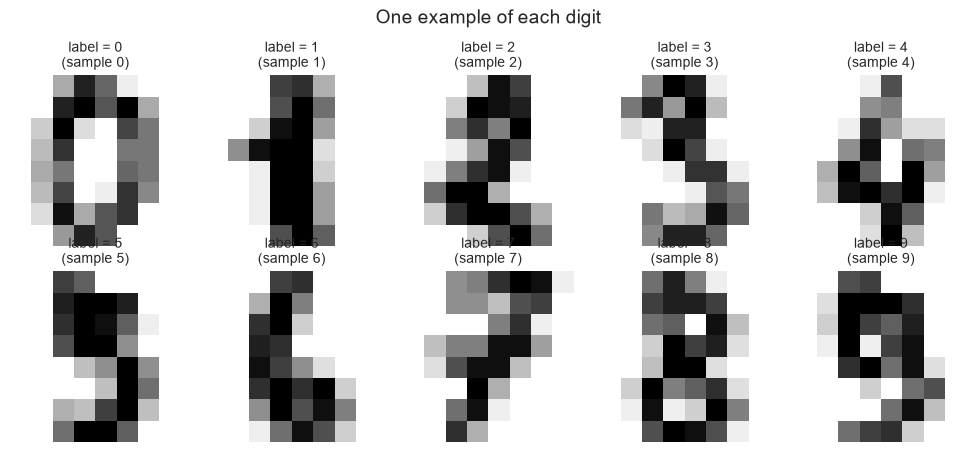

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.6))
for digit, ax in zip(range(10), axes.ravel()):
    idx = np.flatnonzero(y_all == digit)[0]
    ax.imshow(digits.images[idx], cmap="gray_r", interpolation="nearest")
    ax.set_title(f"label = {digit}\n(sample {idx})", fontsize=10)
    ax.axis("off")
plt.suptitle("One example of each digit", fontsize=14)
plt.tight_layout()
plt.show()

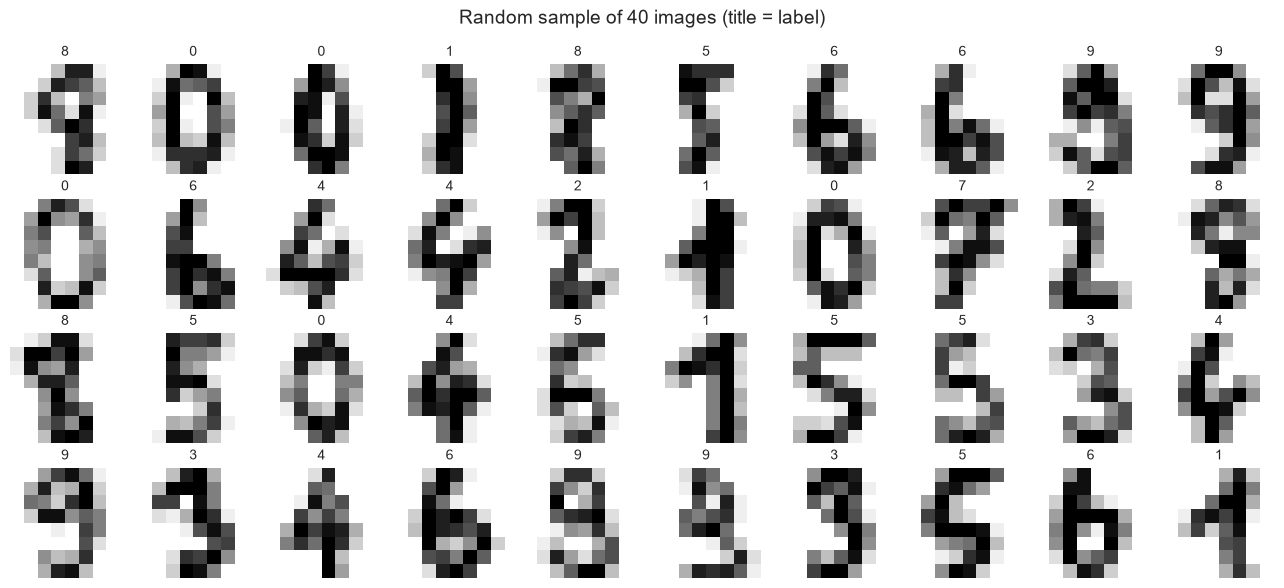

In [15]:
rng = np.random.default_rng(RANDOM_STATE)
random_idx = rng.choice(n_samples, size=40, replace=False)

fig, axes = plt.subplots(4, 10, figsize=(13, 6))
for idx, ax in zip(random_idx, axes.ravel()):
    ax.imshow(digits.images[idx], cmap="gray_r", interpolation="nearest")
    ax.set_title(f"{y_all[idx]}", fontsize=10)
    ax.axis("off")
plt.suptitle("Random sample of 40 images (title = label)", fontsize=14)
plt.tight_layout()
plt.show()

- Low resolution (8×8, 17 grey levels), but the digits are recognisable.
- Visible within-class variability (thickness, slant, position).

### 5.5 Pixel intensity distribution

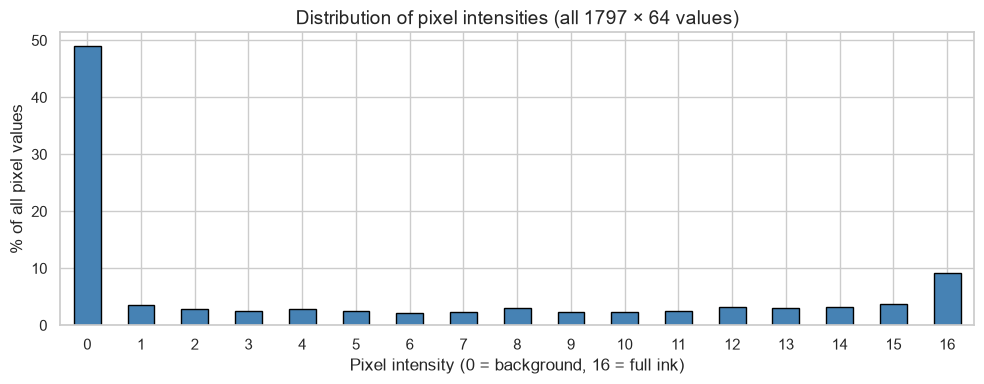

Pixels equal to 0  : 48.93 %
Pixels equal to 16 : 9.09 %
Pixels in 1..15    : 41.98 %


In [16]:
values, counts = np.unique(X_all, return_counts=True)
pixel_value_share = pd.Series(100 * counts / counts.sum(), index=values.astype(int), name="% of all pixels")

plt.figure(figsize=(10, 4))
ax = pixel_value_share.plot(kind="bar", color="steelblue", edgecolor="black")
ax.set_xlabel("Pixel intensity (0 = background, 16 = full ink)")
ax.set_ylabel("% of all pixel values")
ax.set_title("Distribution of pixel intensities (all 1797 × 64 values)", fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Pixels equal to 0  : {pixel_value_share.loc[0]:.2f} %")
print(f"Pixels equal to 16 : {pixel_value_share.loc[16]:.2f} %")
print(f"Pixels in 1..15    : {pixel_value_share.loc[1:15].sum():.2f} %")

### 5.6 Per-pixel statistics and constant features

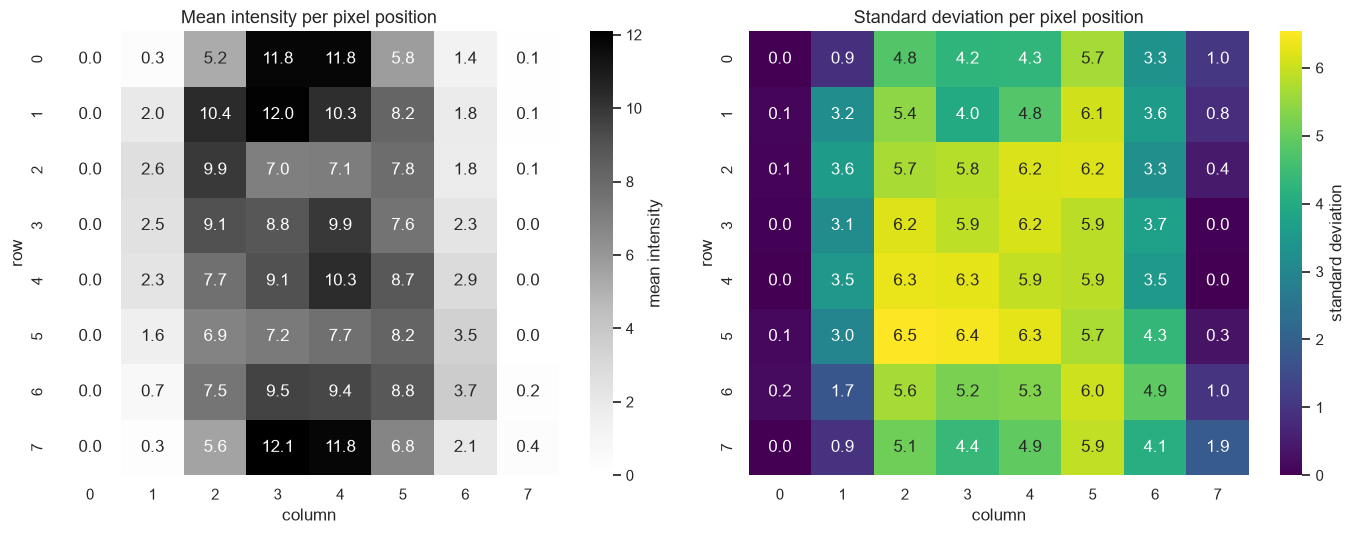

In [17]:
pixel_mean = X_all.mean(axis=0).reshape(8, 8)
pixel_std = X_all.std(axis=0).reshape(8, 8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(pixel_mean, annot=True, fmt=".1f", cmap="Greys", cbar_kws={"label": "mean intensity"}, ax=axes[0])
axes[0].set_title("Mean intensity per pixel position", fontsize=13)
sns.heatmap(pixel_std, annot=True, fmt=".1f", cmap="viridis", cbar_kws={"label": "standard deviation"}, ax=axes[1])
axes[1].set_title("Standard deviation per pixel position", fontsize=13)
for ax in axes:
    ax.set_xlabel("column")
    ax.set_ylabel("row")
plt.tight_layout()
plt.show()

In [18]:
pixel_stats = pd.DataFrame({
    "std": X_all.std(axis=0),
    "% zeros": 100 * (X_all == 0).mean(axis=0),
    "% most frequent value": [100 * np.bincount(col.astype(int)).max() / n_samples for col in X_all.T],
    "max": X_all.max(axis=0),
}, index=digits.feature_names)

constant = pixel_stats[pixel_stats["std"] == 0]
near_constant = pixel_stats[(pixel_stats["std"] > 0) & (pixel_stats["% most frequent value"] >= 95)]

print(f"Constant features (std = 0): {len(constant)} -> {list(constant.index)}")
print(f"Near-constant features (same value in >= 95 % of the samples): {len(near_constant)}")
near_constant.sort_values("% most frequent value", ascending=False).round(3)

Constant features (std = 0): 3 -> ['pixel_0_0', 'pixel_4_0', 'pixel_4_7']
Near-constant features (same value in >= 95 % of the samples): 11


,std,% zeros,% most frequent value,max
pixel_7_0,0.024,99.944,99.944,1.0
pixel_3_0,0.033,99.889,99.889,1.0
pixel_3_7,0.047,99.777,99.777,1.0
pixel_6_0,0.204,99.777,99.777,8.0
pixel_2_0,0.062,99.777,99.777,2.0
pixel_1_0,0.094,99.610,99.610,2.0
pixel_5_0,0.145,99.499,99.499,4.0
pixel_5_7,0.307,98.776,98.776,6.0
pixel_2_7,0.438,98.164,98.164,8.0
pixel_0_7,1.037,97.329,97.329,15.0


- Pixel values are integers in 0–16; ~49 % of all values are 0.
- Information is concentrated in the central columns; the border columns are mostly empty.
- 3 constant and 11 near-constant pixels; all 64 features are kept.
- Near-constant pixels receive very large values when standardised (see 6.4).

### 5.7 Average image per class and similarity between classes

- Correlation between class-mean images, used to anticipate likely confusions.

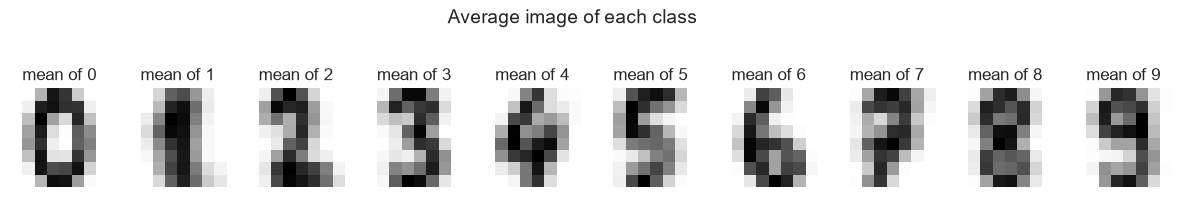

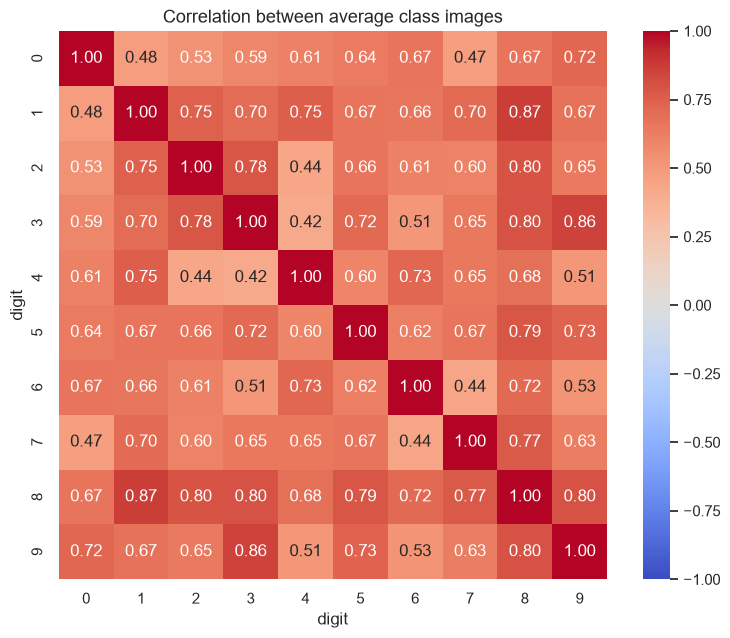

Most similar pairs of average images:
digit A  digit B
1        8          0.867
3        9          0.857
8        9          0.802
3        8          0.800
2        8          0.796
5        8          0.786


In [19]:
class_means = np.array([X_all[y_all == d].mean(axis=0) for d in range(10)])

fig, axes = plt.subplots(1, 10, figsize=(15, 2.2))
for digit, ax in enumerate(axes):
    ax.imshow(class_means[digit].reshape(8, 8), cmap="gray_r", interpolation="nearest")
    ax.set_title(f"mean of {digit}")
    ax.axis("off")
plt.suptitle("Average image of each class", fontsize=14, y=1.08)
plt.show()

class_similarity = pd.DataFrame(np.corrcoef(class_means), index=range(10), columns=range(10))
plt.figure(figsize=(8, 6.5))
sns.heatmap(class_similarity, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation between average class images", fontsize=13)
plt.xlabel("digit")
plt.ylabel("digit")
plt.tight_layout()
plt.show()

pairs = (class_similarity.where(np.triu(np.ones((10, 10), dtype=bool), k=1))
         .stack().sort_values(ascending=False))
pairs.index.names = ["digit A", "digit B"]
print("Most similar pairs of average images:")
print(pairs.head(6).round(3).to_string())

- Most similar class means: 1–8 (0.87), 3–9 (0.86), 8–9 (0.80), 3–8 (0.80).
- Digit 8 appears in 4 of the 6 most similar pairs, so confusions involving 8 are expected.

### 5.8 Modelling Decisions

- No missing values, infinities or duplicates → no cleaning required.
- Balanced classes → no resampling; **stratified 60/20/20 split**.
- Pixels share the 0–16 range, with near-constant border pixels → `StandardScaler` inside a `Pipeline`;
  for KNN, scaling is evaluated as a hyperparameter.
- Balanced 10-class problem → **Macro F1** for model selection, accuracy as a complementary metric,
  confusion matrices for error analysis.

## 6. Data Preparation

### 6.1 Defining X and y

In [ ]:
X = digits.data
y = digits.target
row_ids = np.arange(len(y))  

print("X:", X.shape, "| y:", y.shape)

X: (1797, 64) | y: (1797,)


### 6.2 Train / Validation / Test split (60 / 20 / 20)

- Two stratified steps: 80/20 (train + validation / test), then 75/25 (train / validation).
- `random_state=42`; the same subsets are used by all models.

In [21]:
X_trainval, X_test, y_trainval, y_test, idx_trainval, idx_test = train_test_split(
    X, y, row_ids, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_trainval, y_trainval, idx_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval
)

split_sizes = pd.DataFrame({
    "samples": [len(y_train), len(y_val), len(y_test)],
}, index=["train", "validation", "test"])
split_sizes["% of dataset"] = 100 * split_sizes["samples"] / len(y)
split_sizes.loc["total"] = [split_sizes["samples"].sum(), split_sizes["% of dataset"].sum()]
split_sizes.round(2)

,samples,% of dataset
train,1077.0,59.93
validation,360.0,20.03
test,360.0,20.03
total,1797.0,100.00


### 6.3 Checking the class proportions in each subset

In [22]:
def class_percentages(labels):
    return pd.Series(labels).value_counts(normalize=True).sort_index() * 100

proportions = pd.DataFrame({
    "full dataset": class_percentages(y),
    "train": class_percentages(y_train),
    "validation": class_percentages(y_val),
    "test": class_percentages(y_test),
})
proportions.index.name = "digit"
max_deviation = proportions[["train", "validation", "test"]].sub(proportions["full dataset"], axis=0).abs().max().max()

print(proportions.round(2).to_string())
print(f"\nLargest deviation from the full-dataset proportion: {max_deviation:.2f} percentage points")
print("Overlap train/validation:", len(np.intersect1d(idx_train, idx_val)),
      "| train/test:", len(np.intersect1d(idx_train, idx_test)),
      "| validation/test:", len(np.intersect1d(idx_val, idx_test)))

       full dataset  train  validation   test
digit                                        
0              9.91   9.84       10.00  10.00
1             10.13  10.12       10.28  10.00
2              9.85   9.94        9.72   9.72
3             10.18  10.12       10.28  10.28
4             10.07  10.12       10.00  10.00
5             10.13  10.12       10.00  10.28
6             10.07  10.12       10.00  10.00
7              9.96   9.94       10.00  10.00
8              9.68   9.66        9.72   9.72
9             10.02  10.03       10.00  10.00

Largest deviation from the full-dataset proportion: 0.15 percentage points
Overlap train/validation: 0 | train/test: 0 | validation/test: 0


### 6.4 Feature scaling

- KNN, SVM and MLP are sensitive to the scale of the inputs.
- `StandardScaler` is placed inside a `Pipeline`, so it is fitted only on the rows used for training (no leakage).
- The cell below checks, on the training set only, what standardisation does to near-constant pixels.

In [23]:
scaler_check = StandardScaler().fit(X_train)
Z_train = scaler_check.transform(X_train)

train_std = X_train.std(axis=0)
scaling_check = pd.DataFrame({
    "train std": train_std,
    "StandardScaler scale_": scaler_check.scale_,
    "max |z| in train": np.abs(Z_train).max(axis=0),
}, index=digits.feature_names).sort_values("max |z| in train", ascending=False)

print(f"Per-pixel std in train: min = {train_std.min():.3f}, max = {train_std.max():.3f}")
print(f"Zero-variance pixels in train: {list(np.array(digits.feature_names)[train_std == 0])} "
      f"(StandardScaler keeps scale_ = 1 for them, so they stay constant at 0)")
print("\nPixels with the most extreme standardised values in train:")
scaling_check.head(8).round(3)

Per-pixel std in train: min = 0.000, max = 6.487
Zero-variance pixels in train: [np.str_('pixel_0_0'), np.str_('pixel_3_0'), np.str_('pixel_4_0'), np.str_('pixel_4_7')] (StandardScaler keeps scale_ = 1 for them, so they stay constant at 0)

Pixels with the most extreme standardised values in train:


,train std,StandardScaler scale_,max |z| in train
pixel_7_0,0.030,0.030,32.802
pixel_6_0,0.091,0.091,32.802
pixel_5_0,0.080,0.080,24.791
pixel_1_0,0.080,0.080,24.791
pixel_3_7,0.043,0.043,23.184
pixel_2_0,0.043,0.043,23.184
pixel_5_7,0.275,0.275,21.741
pixel_2_7,0.499,0.499,15.916


- 4 zero-variance pixels (left at 0 by `StandardScaler`).
- Some border pixels reach |z| values of 16–33 after standardisation (typical pixels stay within about ±3).
- SVM / MLP: `StandardScaler` is used.
- KNN: scaling vs no scaling is compared on validation (7.2).

### 6.5 Model Selection

- Primary metric: **Macro F1** on the validation set.
- Gives equal importance to all 10 digit classes.
- Accuracy is reported as a complementary metric.
- Tie-breakers: validation accuracy, then the simpler / cheaper configuration.
- Final test metrics: accuracy, macro and weighted precision / recall / F1, classification report, confusion matrix, times.

### 6.6 Helper functions

- `load_or_compute` / `load_or_train`: reuse a matching checkpoint, or train and save it.
- `run_tuning` / `select_best`: fit candidates on train, score them on validation, rank by Macro F1.
- `evaluate_on_test`: the only access to the Digits test set (final models only, logged).
- `print_test_report`, `plot_confusion`, `top_confusions`: common test report.

#### Metrics and data fingerprints

In [ ]:
def fingerprint(indices):
    return hashlib.sha1(np.sort(np.asarray(indices)).astype(np.int64).tobytes()).hexdigest()[:12]


def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision Macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Precision Weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall Weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1 Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

#### Training and checkpoint helpers

In [ ]:
def fit_with_timing(pipeline, X_fit, y_fit):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        start = time.perf_counter()
        pipeline.fit(X_fit, y_fit)
        fit_time = time.perf_counter() - start
    convergence = [str(w.message) for w in caught if issubclass(w.category, ConvergenceWarning)]
    for w in caught:
        if not issubclass(w.category, ConvergenceWarning):
            warnings.warn_explicit(w.message, w.category, w.filename, w.lineno)
    return fit_time, convergence


def load_or_compute(path, expected, compute, value_key=None):
    # Reuses the file at `path` if every `expected` entry matches (and FORCE_RETRAIN is False); otherwise computes,
    # saves and returns the value. With value_key=None the value is a dict saved as is; otherwise it is stored
    # under value_key next to the expected entries.
    if path.exists() and not FORCE_RETRAIN:
        stored = joblib.load(path)
        if all(stored.get(key) == value for key, value in expected.items()):
            print(f"[checkpoint] loaded {path}")
            return stored if value_key is None else stored[value_key]
        print(f"[checkpoint] {path} does not match the current data/parameters -> recomputing")
    value = compute()
    joblib.dump(value if value_key is None else {**expected, value_key: value}, path)
    print(f"[checkpoint] saved {path}")
    return value


def load_or_train(name, factory, params, X_fit, y_fit, fit_ids):
    def train():
        pipeline = factory(**params)
        fit_time, convergence = fit_with_timing(pipeline, X_fit, y_fit)
        return {"name": name, "pipeline": pipeline, "params": params, "fit_time_s": fit_time,
                "n_samples": len(y_fit), "data_fingerprint": fingerprint(fit_ids),
                "convergence_warnings": convergence, "sklearn_version": sklearn.__version__}

    bundle = load_or_compute(CHECKPOINT_DIR / f"{name}.joblib",
                             {"data_fingerprint": fingerprint(fit_ids), "params": params}, train)
    print(f"  fitted on {bundle['n_samples']} samples, training time {bundle['fit_time_s']:.3f}s")
    for msg in bundle["convergence_warnings"]:
        print("  ConvergenceWarning recorded at training time:", msg)
    return bundle

#### Tuning and model selection

In [26]:
def run_tuning(cache_name, factory, candidates, X_fit, y_fit, fit_ids, X_val, y_val, val_ids,
               extra_info=None, score_train=False, verbose=False):
    # Every candidate is fitted on the TRAINING rows and scored on the VALIDATION rows. The test set is never used here.
    def evaluate_candidates():
        rows = []
        for i, params in enumerate(candidates, start=1):
            pipeline = factory(**params)
            fit_time, convergence = fit_with_timing(pipeline, X_fit, y_fit)
            start = time.perf_counter()
            y_val_pred = pipeline.predict(X_val)
            predict_time = time.perf_counter() - start
            row = {"config": i, **{k: v for k, v in params.items() if k != "input_version"}}
            if score_train:
                y_fit_pred = pipeline.predict(X_fit)
                row.update(train_accuracy=accuracy_score(y_fit, y_fit_pred),
                           train_f1_macro=f1_score(y_fit, y_fit_pred, average="macro"))
            row.update(val_accuracy=accuracy_score(y_val, y_val_pred),
                       val_f1_macro=f1_score(y_val, y_val_pred, average="macro"),
                       fit_time_s=fit_time, val_predict_time_s=predict_time,
                       convergence_warning=bool(convergence), params=params)
            if extra_info is not None:
                row.update(extra_info(pipeline))
            rows.append(row)
            if verbose:
                print(f"  config {i}/{len(candidates)}: val F1 macro {row['val_f1_macro']:.4f} | fit {fit_time:.1f}s | "
                      f"validation prediction {predict_time:.1f}s" + (" | ConvergenceWarning" if convergence else ""))
        return pd.DataFrame(rows)

    expected = {"data_fingerprint": f"{fingerprint(fit_ids)}-{fingerprint(val_ids)}", "candidates": candidates}
    results = load_or_compute(CHECKPOINT_DIR / f"{cache_name}.joblib", expected, evaluate_candidates,
                              value_key="results")
    print(f"  {len(results)} configurations: fitted on {len(fit_ids)} training rows, "
          f"scored on {len(val_ids)} validation rows")
    return results


def select_best(results, tie_breakers):
    order = [("val_f1_macro", False)] + tie_breakers
    ranked = results.sort_values([c for c, _ in order], ascending=[a for _, a in order],
                                 kind="mergesort").reset_index(drop=True)
    return ranked.loc[0, "params"], ranked


def evaluate_on_validation(bundle):
    return compute_metrics(y_val, bundle["pipeline"].predict(X_val))

#### Test-set access and reporting

In [27]:
TEST_SET_LOG = []    # every access to the test set is recorded here
FINAL_RESULTS = {}   # test-set results of the final models, filled in sections 7-9


def evaluate_on_test(bundle):
    if not bundle["name"].endswith("_final"):
        raise ValueError(f"{bundle['name']} is not a final model: the test set is reserved for final models.")
    TEST_SET_LOG.append(bundle["name"])
    start = time.perf_counter()
    y_pred = bundle["pipeline"].predict(X_test)
    pred_time = time.perf_counter() - start
    return y_pred, compute_metrics(y_test, y_pred), pred_time

In [28]:
def print_test_report(title, y_true, y_pred, metrics, details):
    # Header lines, the seven test metrics and the per-class classification report
    print(f"=== {title} ===")
    for label, value in details.items():
        print(f"{label:<16}: {value}")
    print(f"{'Test errors':<16}: {int((y_pred != y_true).sum())} / {len(y_true)}\n")
    print(pd.Series(metrics).round(4).to_string())
    print("\n--- Classification report (per class) ---")
    print(classification_report(y_true, y_pred, digits=4))


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(10))
    plt.figure(figsize=(8, 6.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted digit")
    plt.ylabel("True digit")
    plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def top_confusions(y_true, y_pred, n=6):
    cm = confusion_matrix(y_true, y_pred, labels=range(10))
    np.fill_diagonal(cm, 0)
    pairs = [(t, p, cm[t, p]) for t in range(10) for p in range(10) if cm[t, p] > 0]
    pairs.sort(key=lambda item: -item[2])
    return pd.DataFrame(pairs[:n], columns=["true digit", "predicted digit", "count"])


def show_test_results(model_label, bundle, y_pred, metrics, pred_time):
    print_test_report(f"{model_label} — evaluation on the TEST set", y_test, y_pred, metrics, {
        "Hyperparameters": bundle["params"],
        "Trained on": f"{bundle['n_samples']} samples (train + validation)",
        "Training time": f"{bundle['fit_time_s']:.4f} s | Prediction time (test): {pred_time:.4f} s",
    })


def show_misclassified(y_pred, title, max_images=12):
    wrong = np.flatnonzero(y_pred != y_test)[:max_images]
    if len(wrong) == 0:
        print("No misclassified test images.")
        return
    fig, axes = plt.subplots(1, len(wrong), figsize=(1.3 * len(wrong), 2))
    for ax, i in zip(np.atleast_1d(axes), wrong):
        ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r", interpolation="nearest")
        ax.set_title(f"true {y_test[i]}\npred {y_pred[i]}", fontsize=9)
        ax.axis("off")
    plt.suptitle(title, fontsize=12, y=1.12)
    plt.show()

## 7. K-Nearest Neighbours (KNN)

### 7.1 Baseline

- `StandardScaler` + `KNeighborsClassifier(n_neighbors=5)`; fitted on train, scored on validation.

In [29]:
def make_knn(scaler="standard", **knn_params):
    return Pipeline([
        ("scaler", StandardScaler() if scaler == "standard" else "passthrough"),
        ("classifier", KNeighborsClassifier(**knn_params)),
    ])


knn_baseline_params = {"scaler": "standard", "n_neighbors": 5}
knn_baseline = load_or_train("knn_baseline", make_knn, knn_baseline_params, X_train, y_train, idx_train)

knn_baseline_val = evaluate_on_validation(knn_baseline)
pd.Series(knn_baseline_val, name="KNN baseline (validation)").round(4).to_frame()

[checkpoint] loaded checkpoints\knn_baseline.joblib
  fitted on 1077 samples, training time 0.002s


,KNN baseline (validation)
Accuracy,0.9611
Precision Macro,0.9663
Recall Macro,0.9607
F1 Macro,0.9616
Precision Weighted,0.9657
Recall Weighted,0.9611
F1 Weighted,0.9615


### 7.2 Tuning

- `k` ∈ {1–15, 20, 25, 30}; `weights` ∈ {uniform, distance}; `scaler` ∈ {standard, none} → 72 configurations.
- Tie-breakers: validation accuracy, then the larger `k`.

In [30]:
k_values = list(range(1, 16)) + [20, 25, 30]
knn_candidates = [
    {"scaler": scaler, "n_neighbors": k, "weights": weights}
    for scaler in ["standard", "none"]
    for weights in ["uniform", "distance"]
    for k in k_values
]

knn_results = run_tuning("knn_tuning_results", make_knn, knn_candidates, X_train, y_train, idx_train, X_val, y_val, idx_val, score_train=True)
knn_best_params, knn_ranked = select_best(
    knn_results, tie_breakers=[("val_accuracy", False), ("n_neighbors", False)]
)

knn_columns = ["scaler", "weights", "n_neighbors", "train_f1_macro", "val_accuracy", "val_f1_macro"]
print(f"{len(knn_results)} configurations evaluated. Top 10 by validation F1 macro:")
knn_ranked[knn_columns].head(10)

[checkpoint] loaded checkpoints\knn_tuning_results.joblib
  72 configurations: fitted on 1077 training rows, scored on 360 validation rows
72 configurations evaluated. Top 10 by validation F1 macro:


,scaler,weights,n_neighbors,train_f1_macro,val_accuracy,val_f1_macro
0,none,distance,2,1.0000,0.9889,0.9889
1,none,uniform,1,1.0000,0.9889,0.9889
2,none,distance,1,1.0000,0.9889,0.9889
3,none,distance,4,1.0000,0.9861,0.9862
4,none,uniform,2,0.9907,0.9833,0.9832
5,none,distance,6,1.0000,0.9806,0.9807
6,none,uniform,5,0.9925,0.9806,0.9807
7,none,distance,5,1.0000,0.9806,0.9807
8,none,uniform,4,0.9916,0.9806,0.9806
9,none,distance,8,1.0000,0.9806,0.9806


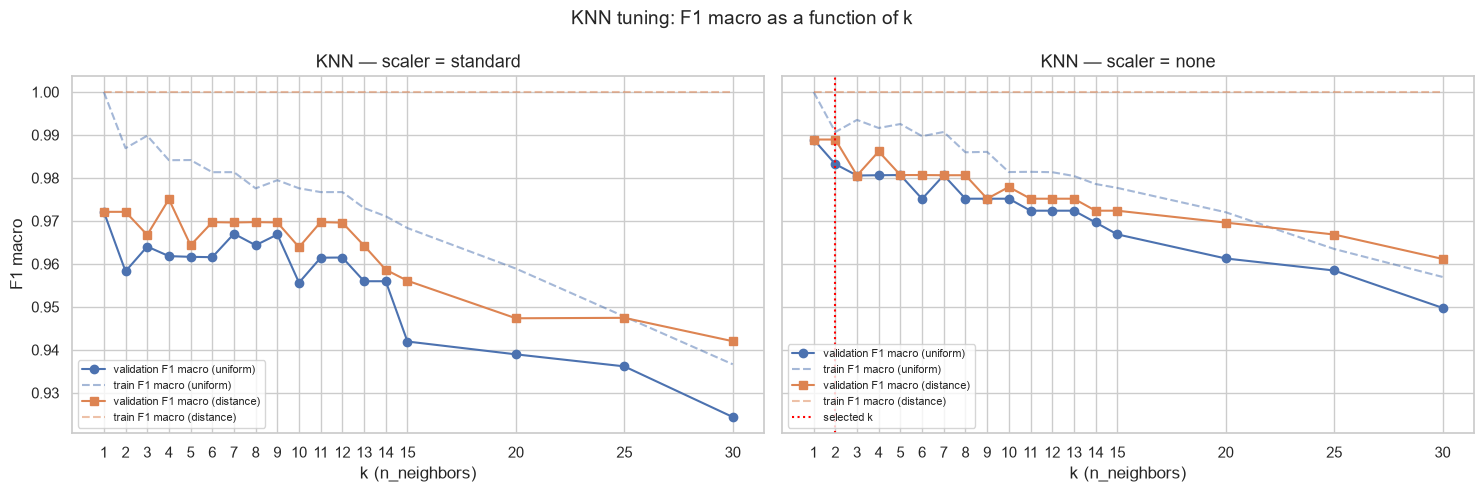

Validation F1 macro per (scaler, weights) group over all k:
                     mean     max
scaler   weights                 
none     distance  0.9771  0.9889
         uniform   0.9732  0.9889
standard distance  0.9638  0.9751
         uniform   0.9561  0.9721


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, scaler in zip(axes, ["standard", "none"]):
    for weights, marker in [("uniform", "o"), ("distance", "s")]:
        curve = knn_results[(knn_results["scaler"] == scaler) & (knn_results["weights"] == weights)]
        curve = curve.sort_values("n_neighbors")
        line, = ax.plot(curve["n_neighbors"], curve["val_f1_macro"], marker=marker,
                        label=f"validation F1 macro ({weights})")
        ax.plot(curve["n_neighbors"], curve["train_f1_macro"], linestyle="--", color=line.get_color(),
                alpha=0.5, label=f"train F1 macro ({weights})")
    if knn_best_params["scaler"] == scaler:
        ax.axvline(knn_best_params["n_neighbors"], color="red", linestyle=":", label="selected k")
    ax.set_title(f"KNN — scaler = {scaler}", fontsize=13)
    ax.set_xlabel("k (n_neighbors)")
    ax.set_xticks(k_values)
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("F1 macro")
plt.suptitle("KNN tuning: F1 macro as a function of k", fontsize=14)
plt.tight_layout()
plt.show()

summary_by_group = (knn_results.groupby(["scaler", "weights"])["val_f1_macro"]
                    .agg(["mean", "max"]).round(4))
print("Validation F1 macro per (scaler, weights) group over all k:")
print(summary_by_group.to_string())

- Best: `scaler=none`, `k=2`, `weights=distance` — validation Macro F1 **0.9889** (baseline 0.9616).
- Standardisation reduced validation Macro F1 for every `k` tested (best 0.9751 vs 0.9889).
- Changes in the distance geometry (relative weight of low-variance peripheral pixels) may contribute;
  the experiment does not isolate the cause.
- Small `k` performed best; validation Macro F1 decreases as `k` grows.
- Three configurations tied at 0.9889; the tie-breaker kept `k=2`.

### 7.3 Selected configuration (validation)

In [32]:
print("Selected KNN hyperparameters:", knn_best_params)
knn_best_validation = load_or_train("knn_best_validation", make_knn, knn_best_params, X_train, y_train, idx_train)

pd.DataFrame({
    "baseline (validation)": knn_baseline_val,
    "best configuration (validation)": evaluate_on_validation(knn_best_validation),
}).round(4)

Selected KNN hyperparameters: {'scaler': 'none', 'n_neighbors': 2, 'weights': 'distance'}
[checkpoint] loaded checkpoints\knn_best_validation.joblib
  fitted on 1077 samples, training time 0.001s


,baseline (validation),best configuration (validation)
Accuracy,0.9611,0.9889
Precision Macro,0.9663,0.9897
Recall Macro,0.9607,0.9887
F1 Macro,0.9616,0.9889
Precision Weighted,0.9657,0.9895
Recall Weighted,0.9611,0.9889
F1 Weighted,0.9615,0.9889


### 7.4 Final model (train + validation)

In [33]:
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])
idx_train_val = np.concatenate([idx_train, idx_val])
print("Train + validation:", X_train_val.shape, "| test (still unused):", X_test.shape)

knn_final = load_or_train("knn_final", make_knn, knn_best_params, X_train_val, y_train_val, idx_train_val)

Train + validation: (1437, 64) | test (still unused): (360, 64)
[checkpoint] loaded checkpoints\knn_final.joblib
  fitted on 1437 samples, training time 0.001s


### 7.5 Final test

=== KNN final — evaluation on the TEST set ===
Hyperparameters : {'scaler': 'none', 'n_neighbors': 2, 'weights': 'distance'}
Trained on      : 1437 samples (train + validation)
Training time   : 0.0014 s | Prediction time (test): 0.0040 s
Test errors     : 5 / 360

Accuracy              0.9861
Precision Macro       0.9866
Recall Macro          0.9859
F1 Macro              0.9859
Precision Weighted    0.9867
Recall Weighted       0.9861
F1 Weighted           0.9861

--- Classification report (per class) ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        36
           1     0.9231    1.0000    0.9600        36
           2     1.0000    1.0000    1.0000        35
           3     1.0000    1.0000    1.0000        37
           4     0.9730    1.0000    0.9863        36
           5     1.0000    1.0000    1.0000        37
           6     1.0000    1.0000    1.0000        36
           7     1.0000    1.0000    1.0000        36
 

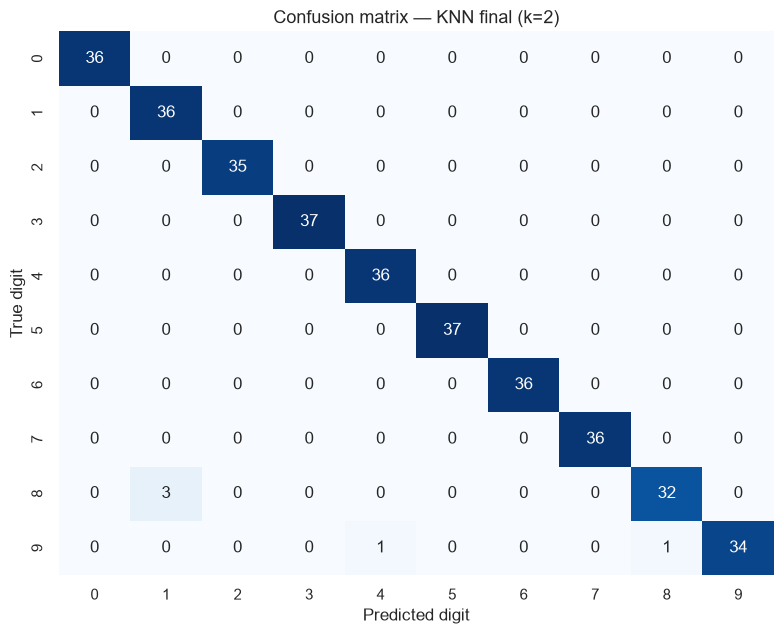

In [34]:
y_pred_knn, knn_test_metrics, knn_pred_time = evaluate_on_test(knn_final)
FINAL_RESULTS["KNN"] = {"bundle": knn_final, "y_pred": y_pred_knn,
                        "metrics": knn_test_metrics, "pred_time": knn_pred_time}

show_test_results("KNN final", knn_final, y_pred_knn, knn_test_metrics, knn_pred_time)
plot_confusion(y_test, y_pred_knn, f"Confusion matrix — KNN final (k={knn_best_params['n_neighbors']})")

Most frequent confusions (KNN):
 true digit  predicted digit  count
          8                1      3
          9                4      1
          9                8      1


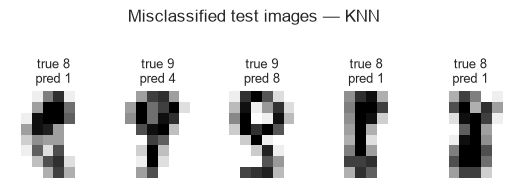

In [35]:
print("Most frequent confusions (KNN):")
print(top_confusions(y_test, y_pred_knn).to_string(index=False))
show_misclassified(y_pred_knn, "Misclassified test images — KNN")

- Accuracy **0.9861**, Macro F1 **0.9859**, 5 errors / 360.
- Main confusion: 8 → 1 (3 errors), the pair with the most similar class means in the EDA.

## 8. Support Vector Machine (SVM)

### 8.1 Baseline

- `StandardScaler` + `SVC` (RBF, `C=1`, `gamma="scale"`).

In [36]:
def make_svm(**svm_params):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(random_state=RANDOM_STATE, **svm_params)),
    ])


svm_baseline_params = {"kernel": "rbf", "C": 1.0, "gamma": "scale"}
svm_baseline = load_or_train("svm_baseline", make_svm, svm_baseline_params, X_train, y_train, idx_train)

svm_baseline_val = evaluate_on_validation(svm_baseline)
pd.Series(svm_baseline_val, name="SVM baseline (validation)").round(4).to_frame()

[checkpoint] loaded checkpoints\svm_baseline.joblib
  fitted on 1077 samples, training time 0.031s


,SVM baseline (validation)
Accuracy,0.9889
Precision Macro,0.9894
Recall Macro,0.9887
F1 Macro,0.9888
Precision Weighted,0.9893
Recall Weighted,0.9889
F1 Weighted,0.9889


### 8.2 Tuning

- 27 configurations: linear (5 values of `C`), RBF (4 `C` × 4 `gamma`), polynomial (degree 2–3 × 3 `C`).
- Tie-breakers: validation accuracy, fewer support vectors, smaller `C`.

In [37]:
svm_candidates = (
    [{"kernel": "linear", "C": C} for C in [0.001, 0.01, 0.1, 1.0, 10.0]]
    + [{"kernel": "rbf", "C": C, "gamma": gamma}
       for C in [0.1, 1.0, 10.0, 100.0] for gamma in ["scale", 0.001, 0.01, 0.1]]
    + [{"kernel": "poly", "degree": degree, "C": C, "gamma": "scale"}
       for degree in [2, 3] for C in [0.1, 1.0, 10.0]]
)


def svm_extra_info(pipeline):
    return {"n_support_vectors": int(pipeline.named_steps["classifier"].n_support_.sum())}


svm_results = run_tuning("svm_tuning_results", make_svm, svm_candidates, X_train, y_train, idx_train, X_val, y_val, idx_val,
                         extra_info=svm_extra_info, score_train=True)
svm_best_params, svm_ranked = select_best(
    svm_results, tie_breakers=[("val_accuracy", False), ("n_support_vectors", True), ("C", True)]
)

svm_columns = ["kernel", "C", "gamma", "degree", "train_f1_macro", "val_accuracy", "val_f1_macro",
               "n_support_vectors", "fit_time_s"]
print(f"{len(svm_results)} configurations evaluated. Top 10 by validation F1 macro:")
svm_ranked[svm_columns].head(10)

[checkpoint] loaded checkpoints\svm_tuning_results.joblib
  27 configurations: fitted on 1077 training rows, scored on 360 validation rows
27 configurations evaluated. Top 10 by validation F1 macro:


,kernel,C,gamma,degree,train_f1_macro,val_accuracy,val_f1_macro,n_support_vectors,fit_time_s
0,rbf,100.0,0.01,NaN,1.0000,0.9944,0.9944,539,0.0222
1,rbf,10.0,0.01,NaN,1.0000,0.9944,0.9944,540,0.0219
2,rbf,100.0,0.001,NaN,1.0000,0.9917,0.9917,403,0.0180
3,rbf,10.0,scale,NaN,1.0000,0.9917,0.9916,602,0.0274
4,rbf,100.0,scale,NaN,1.0000,0.9917,0.9916,602,0.0391
5,linear,1.0,NaN,NaN,1.0000,0.9917,0.9916,382,0.0142
6,linear,10.0,NaN,NaN,1.0000,0.9917,0.9916,382,0.0151
7,rbf,1.0,0.01,NaN,0.9963,0.9889,0.9888,598,0.0256
8,rbf,1.0,scale,NaN,0.9963,0.9889,0.9888,612,0.0274
9,linear,0.1,NaN,NaN,0.9972,0.9889,0.9888,398,0.0148


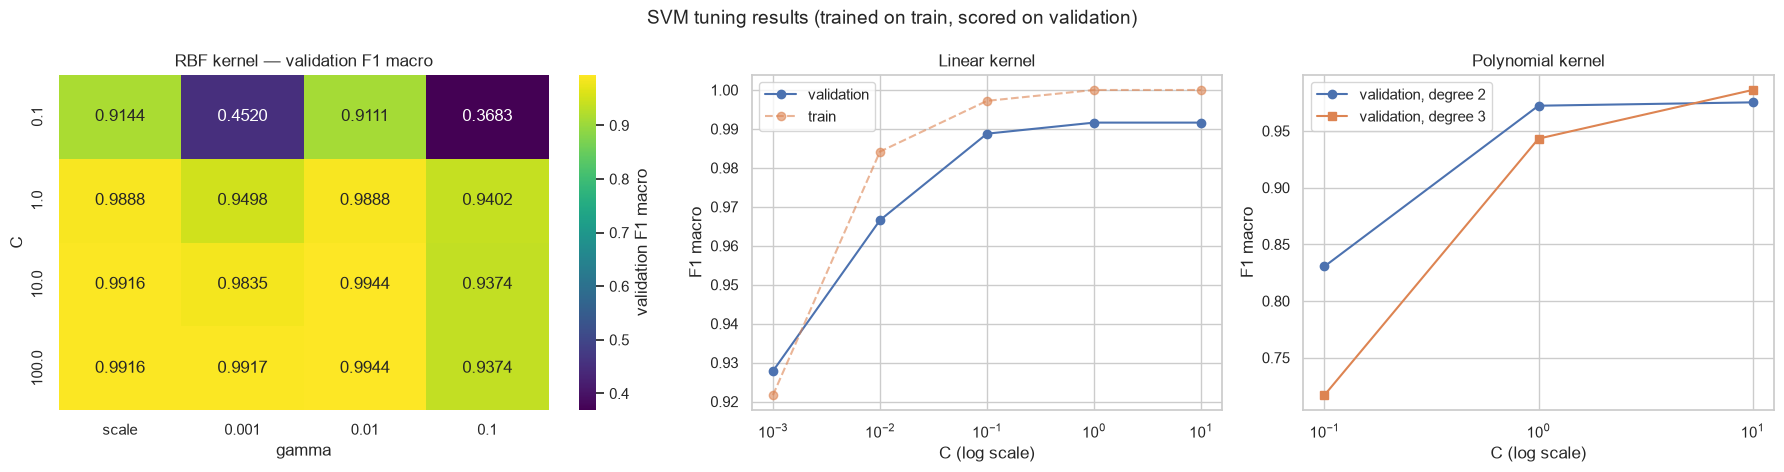

Best validation F1 macro per kernel:
kernel
linear    0.9916
poly      0.9861
rbf       0.9944


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), gridspec_kw={"width_ratios": [1.3, 1, 1]})

rbf = svm_results[svm_results["kernel"] == "rbf"].copy()
rbf["gamma"] = rbf["gamma"].astype(str)
rbf_table = rbf.pivot(index="C", columns="gamma", values="val_f1_macro")[["scale", "0.001", "0.01", "0.1"]]
sns.heatmap(rbf_table, annot=True, fmt=".4f", cmap="viridis", ax=axes[0], cbar_kws={"label": "validation F1 macro"})
axes[0].set_title("RBF kernel — validation F1 macro", fontsize=12)

linear = svm_results[svm_results["kernel"] == "linear"]
axes[1].plot(linear["C"], linear["val_f1_macro"], marker="o", label="validation")
axes[1].plot(linear["C"], linear["train_f1_macro"], marker="o", linestyle="--", alpha=0.6, label="train")
axes[1].set_xscale("log")
axes[1].set_title("Linear kernel", fontsize=12)
axes[1].set_xlabel("C (log scale)")
axes[1].set_ylabel("F1 macro")
axes[1].legend()

for degree, marker in [(2, "o"), (3, "s")]:
    poly = svm_results[(svm_results["kernel"] == "poly") & (svm_results["degree"] == degree)]
    axes[2].plot(poly["C"], poly["val_f1_macro"], marker=marker, label=f"validation, degree {degree:g}")
axes[2].set_xscale("log")
axes[2].set_title("Polynomial kernel", fontsize=12)
axes[2].set_xlabel("C (log scale)")
axes[2].set_ylabel("F1 macro")
axes[2].legend()

plt.suptitle("SVM tuning results (trained on train, scored on validation)", fontsize=14)
plt.tight_layout()
plt.show()

print("Best validation F1 macro per kernel:")
print(svm_results.groupby("kernel")["val_f1_macro"].max().round(4).to_string())

- Baseline validation Macro F1: 0.9888.
- Best: RBF, `C=100`, `gamma=0.01` — validation Macro F1 **0.9944** (tied with `C=10`; fewer support vectors).
- Linear kernel: up to 0.9916; polynomial kernel: up to 0.9861.
- `gamma=0.1` over-fits (train F1 = 1, validation ≈ 0.94); `C=0.1` under-fits.

### 8.3 Selected configuration (validation)

In [39]:
print("Selected SVM hyperparameters:", svm_best_params)
svm_best_validation = load_or_train("svm_best_validation", make_svm, svm_best_params, X_train, y_train, idx_train)

pd.DataFrame({
    "baseline (validation)": svm_baseline_val,
    "best configuration (validation)": evaluate_on_validation(svm_best_validation),
}).round(4)

Selected SVM hyperparameters: {'kernel': 'rbf', 'C': 100.0, 'gamma': 0.01}
[checkpoint] loaded checkpoints\svm_best_validation.joblib
  fitted on 1077 samples, training time 0.024s


,baseline (validation),best configuration (validation)
Accuracy,0.9889,0.9944
Precision Macro,0.9894,0.9946
Recall Macro,0.9887,0.9944
F1 Macro,0.9888,0.9944
Precision Weighted,0.9893,0.9946
Recall Weighted,0.9889,0.9944
F1 Weighted,0.9889,0.9944


### 8.4 Final model (train + validation)

In [40]:
svm_final = load_or_train("svm_final", make_svm, svm_best_params, X_train_val, y_train_val, idx_train_val)

[checkpoint] loaded checkpoints\svm_final.joblib
  fitted on 1437 samples, training time 0.031s


### 8.5 Final test

=== SVM final — evaluation on the TEST set ===
Hyperparameters : {'kernel': 'rbf', 'C': 100.0, 'gamma': 0.01}
Trained on      : 1437 samples (train + validation)
Training time   : 0.0312 s | Prediction time (test): 0.0167 s
Test errors     : 6 / 360

Accuracy              0.9833
Precision Macro       0.9839
Recall Macro          0.9832
F1 Macro              0.9832
Precision Weighted    0.9839
Recall Weighted       0.9833
F1 Weighted           0.9833

--- Classification report (per class) ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        36
           1     0.9722    0.9722    0.9722        36
           2     1.0000    1.0000    1.0000        35
           3     1.0000    1.0000    1.0000        37
           4     0.9459    0.9722    0.9589        36
           5     1.0000    1.0000    1.0000        37
           6     0.9730    1.0000    0.9863        36
           7     0.9474    1.0000    0.9730        36
           8    

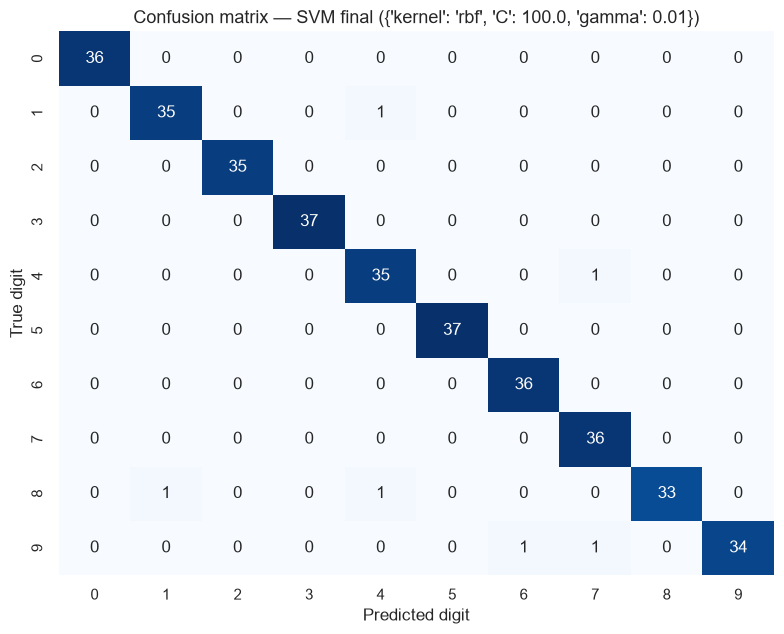

In [41]:
y_pred_svm, svm_test_metrics, svm_pred_time = evaluate_on_test(svm_final)
FINAL_RESULTS["SVM"] = {"bundle": svm_final, "y_pred": y_pred_svm,
                        "metrics": svm_test_metrics, "pred_time": svm_pred_time}

show_test_results("SVM final", svm_final, y_pred_svm, svm_test_metrics, svm_pred_time)
plot_confusion(y_test, y_pred_svm, f"Confusion matrix — SVM final ({svm_best_params})")

Most frequent confusions (SVM):
 true digit  predicted digit  count
          1                4      1
          4                7      1
          8                1      1
          8                4      1
          9                6      1
          9                7      1


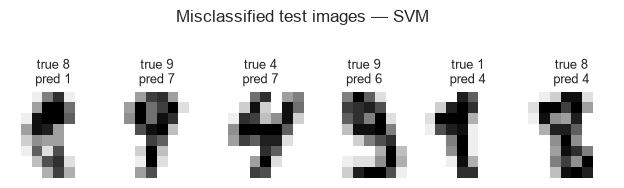

In [42]:
print("Most frequent confusions (SVM):")
print(top_confusions(y_test, y_pred_svm).to_string(index=False))
show_misclassified(y_pred_svm, "Misclassified test images — SVM")

- Accuracy **0.9833**, Macro F1 **0.9832**, 6 errors / 360.
- Errors are spread over six different pairs (one error each).
- Test Macro F1 is 1.1 points below validation (≈ 4 images), consistent with an optimistic validation estimate
  after selecting the best of 27 configurations.

## 9. Multi-Layer Perceptron (MLP)

### 9.1 Baseline

- `StandardScaler` + `MLPClassifier` defaults: `(100,)`, ReLU, `alpha=1e-4`, `learning_rate_init=1e-3`,
  `max_iter=200`, `random_state=42`.

In [43]:
def make_mlp(**mlp_params):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", MLPClassifier(random_state=RANDOM_STATE, **mlp_params)),
    ])


def mlp_params(hidden=(100,), activation="relu", alpha=1e-4, lr=1e-3, max_iter=200):
    return {"hidden_layer_sizes": hidden, "activation": activation, "alpha": alpha,
            "learning_rate_init": lr, "max_iter": max_iter}


mlp_baseline_params = mlp_params()
mlp_baseline = load_or_train("mlp_baseline", make_mlp, mlp_baseline_params, X_train, y_train, idx_train)

baseline_net = mlp_baseline["pipeline"].named_steps["classifier"]
print(f"Epochs run: {baseline_net.n_iter_} / {baseline_net.max_iter} | "
      f"converged: {baseline_net.n_iter_ < baseline_net.max_iter} | final training loss: {baseline_net.loss_:.5f}")

mlp_baseline_val = evaluate_on_validation(mlp_baseline)
pd.Series(mlp_baseline_val, name="MLP baseline (validation)").round(4).to_frame()

[checkpoint] loaded checkpoints\mlp_baseline.joblib
  fitted on 1077 samples, training time 0.678s
Epochs run: 162 / 200 | converged: True | final training loss: 0.00626


,MLP baseline (validation)
Accuracy,0.9833
Precision Macro,0.9842
Recall Macro,0.9831
F1 Macro,0.9833
Precision Weighted,0.9840
Recall Weighted,0.9833
F1 Weighted,0.9834


### 9.2 Tuning

One factor at a time from the baseline (14 configurations):

| Factor | Values tested |
|---|---|
| `hidden_layer_sizes` | (32,), (64,), (100,), (256,), (64, 32), (128, 64) |
| `activation` | relu, tanh, logistic |
| `alpha` | 1e-4, 1e-3, 1e-2, 1e-1, 1 |
| `learning_rate_init` | 1e-4, 1e-3, 1e-2 |

- Tie-breakers: validation accuracy, fewer parameters, fewer epochs.

In [44]:
mlp_design = (
    [("architecture", mlp_params(hidden=h)) for h in [(32,), (64,), (100,), (256,), (64, 32), (128, 64)]]
    + [("activation", mlp_params(activation=a)) for a in ["tanh", "logistic"]]
    + [("alpha", mlp_params(alpha=a)) for a in [1e-3, 1e-2, 1e-1, 1.0]]
    + [("learning rate", mlp_params(lr=lr)) for lr in [1e-4, 1e-2]]
)
mlp_candidates = [params for _, params in mlp_design]


def mlp_extra_info(pipeline):
    net = pipeline.named_steps["classifier"]
    return {
        "epochs": net.n_iter_,
        "converged": net.n_iter_ < net.max_iter,
        "final_loss": net.loss_,
        "n_parameters": sum(w.size for w in net.coefs_) + sum(b.size for b in net.intercepts_),
    }


mlp_results = run_tuning("mlp_tuning_results", make_mlp, mlp_candidates, X_train, y_train, idx_train, X_val, y_val, idx_val,
                         extra_info=mlp_extra_info, score_train=True)
mlp_results["factor"] = [factor for factor, _ in mlp_design]

mlp_columns = ["config", "factor", "hidden_layer_sizes", "activation", "alpha", "learning_rate_init", "max_iter",
               "epochs", "converged", "final_loss", "train_f1_macro", "val_accuracy", "val_f1_macro",
               "n_parameters", "fit_time_s"]
mlp_results[mlp_columns]

[checkpoint] loaded checkpoints\mlp_tuning_results.joblib
  14 configurations: fitted on 1077 training rows, scored on 360 validation rows


,config,factor,hidden_layer_sizes,activation,alpha,learning_rate_init,max_iter,epochs,converged,final_loss,train_f1_macro,val_accuracy,val_f1_macro,n_parameters,fit_time_s
0,1,architecture,"(32,)",relu,0.0001,0.0010,200,200,False,0.0127,1.0000,0.9694,0.9694,2410,0.4545
1,2,architecture,"(64,)",relu,0.0001,0.0010,200,177,True,0.0071,1.0000,0.9750,0.9751,4810,0.6054
2,3,architecture,"(100,)",relu,0.0001,0.0010,200,162,True,0.0063,1.0000,0.9833,0.9833,7510,0.6431
3,4,architecture,"(256,)",relu,0.0001,0.0010,200,115,True,0.0044,1.0000,0.9806,0.9806,19210,3.1618
4,5,architecture,"(64, 32)",relu,0.0001,0.0010,200,122,True,0.0038,1.0000,0.9667,0.9666,6570,0.5400
5,6,architecture,"(128, 64)",relu,0.0001,0.0010,200,88,True,0.0027,1.0000,0.9833,0.9831,17226,0.6236
6,7,activation,"(100,)",tanh,0.0001,0.0010,200,189,True,0.0076,1.0000,0.9778,0.9779,7510,0.9252
7,8,activation,"(100,)",logistic,0.0001,0.0010,200,200,False,0.0341,0.9991,0.9833,0.9834,7510,0.8436
8,9,alpha,"(100,)",relu,0.0010,0.0010,200,162,True,0.0067,1.0000,0.9833,0.9833,7510,0.7635
9,10,alpha,"(100,)",relu,0.0100,0.0010,200,162,True,0.0113,1.0000,0.9833,0.9833,7510,0.8640


#### 9.2.1 Convergence check

- Configurations that hit `max_iter` are retrained with `max_iter=1000` and kept as separate rows.

In [45]:
not_converged = mlp_results[~mlp_results["converged"]]
print(f"Configurations that did not converge within max_iter: {len(not_converged)}")

if len(not_converged) > 0:
    print(not_converged[["config", "factor", "hidden_layer_sizes", "activation", "alpha",
                         "learning_rate_init", "epochs", "final_loss", "val_f1_macro"]].to_string(index=False))
    followup_design = [(f"{factor} (max_iter=1000)", {**params, "max_iter": 1000})
                       for factor, params in zip(not_converged["factor"], not_converged["params"])]
    followup_results = run_tuning("mlp_followup_tuning_results", make_mlp, [p for _, p in followup_design],
                                  X_train, y_train, idx_train, X_val, y_val, idx_val, extra_info=mlp_extra_info, score_train=True)
    followup_results["factor"] = [factor for factor, _ in followup_design]
    mlp_results_all = pd.concat([mlp_results, followup_results], ignore_index=True)
    mlp_results_all["config"] = np.arange(1, len(mlp_results_all) + 1)
    print("\nAfter re-training with max_iter = 1000:")
    print(followup_results[["factor", "hidden_layer_sizes", "activation", "alpha", "learning_rate_init",
                            "epochs", "converged", "final_loss", "val_f1_macro"]].to_string(index=False))
else:
    mlp_results_all = mlp_results

Configurations that did not converge within max_iter: 4
 config        factor hidden_layer_sizes activation  alpha  learning_rate_init  epochs  final_loss  val_f1_macro
      1  architecture              (32,)       relu 0.0001              0.0010     200      0.0127        0.9694
      8    activation             (100,)   logistic 0.0001              0.0010     200      0.0341        0.9834
     12         alpha             (100,)       relu 1.0000              0.0010     200      0.1806        0.9779
     13 learning rate             (100,)       relu 0.0001              0.0001     200      0.2123        0.9388
[checkpoint] loaded checkpoints\mlp_followup_tuning_results.joblib
  4 configurations: fitted on 1077 training rows, scored on 360 validation rows

After re-training with max_iter = 1000:
                       factor hidden_layer_sizes activation  alpha  learning_rate_init  epochs  converged  final_loss  val_f1_macro
 architecture (max_iter=1000)              (32,)       relu

- 4 of 14 configurations raised `ConvergenceWarning`: `(32,)`, logistic, `alpha=1`, `learning_rate_init=1e-4`.
- With `max_iter=1000` all four converged; the largest change was `learning_rate_init=1e-4` (0.939 → 0.978).

Top 10 MLP configurations by validation F1 macro:


,config,factor,hidden_layer_sizes,activation,alpha,learning_rate_init,max_iter,epochs,converged,final_loss,train_f1_macro,val_accuracy,val_f1_macro,n_parameters,fit_time_s
0,14,learning rate,"(100,)",relu,0.0001,0.010,200,41,True,0.0012,1.0000,0.9861,0.9861,7510,0.2459
1,8,activation,"(100,)",logistic,0.0001,0.001,200,200,False,0.0341,0.9991,0.9833,0.9834,7510,0.8436
2,16,activation (max_iter=1000),"(100,)",logistic,0.0001,0.001,1000,326,True,0.0126,1.0000,0.9833,0.9834,7510,1.4690
3,3,architecture,"(100,)",relu,0.0001,0.001,200,162,True,0.0063,1.0000,0.9833,0.9833,7510,0.6431
4,9,alpha,"(100,)",relu,0.0010,0.001,200,162,True,0.0067,1.0000,0.9833,0.9833,7510,0.7635
5,10,alpha,"(100,)",relu,0.0100,0.001,200,162,True,0.0113,1.0000,0.9833,0.9833,7510,0.8640
6,6,architecture,"(128, 64)",relu,0.0001,0.001,200,88,True,0.0027,1.0000,0.9833,0.9831,17226,0.6236
7,17,alpha (max_iter=1000),"(100,)",relu,1.0000,0.001,1000,329,True,0.1706,0.9991,0.9806,0.9806,7510,1.3904
8,4,architecture,"(256,)",relu,0.0001,0.001,200,115,True,0.0044,1.0000,0.9806,0.9806,19210,3.1618
9,11,alpha,"(100,)",relu,0.1000,0.001,200,179,True,0.0442,1.0000,0.9806,0.9806,7510,0.8139


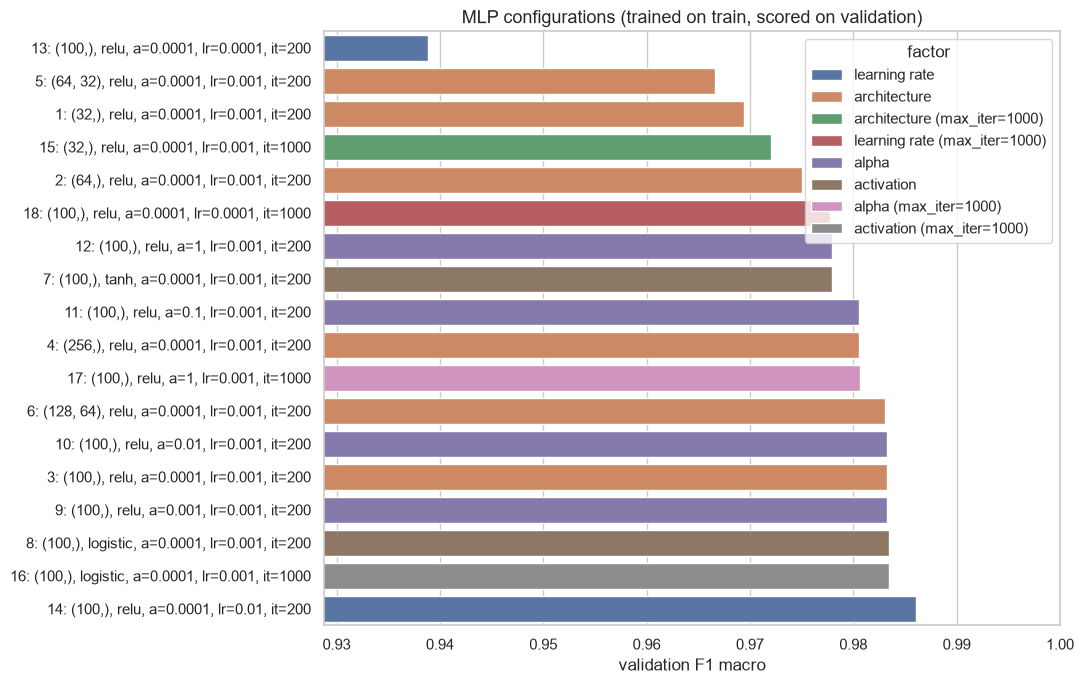

In [46]:
mlp_best_params, mlp_ranked = select_best(
    mlp_results_all, tie_breakers=[("val_accuracy", False), ("n_parameters", True), ("epochs", True)]
)
print("Top 10 MLP configurations by validation F1 macro:")
display(mlp_ranked[mlp_columns].head(10))

plot_data = mlp_results_all.copy()
plot_data["label"] = [
    f"{r.config}: {r.hidden_layer_sizes}, {r.activation}, a={r.alpha:g}, lr={r.learning_rate_init:g}, it={r.max_iter}"
    for r in plot_data.itertuples()
]
plot_data = plot_data.sort_values("val_f1_macro")

plt.figure(figsize=(11, 7))
ax = sns.barplot(data=plot_data, y="label", x="val_f1_macro", hue="factor", dodge=False)
ax.set_xlim(plot_data["val_f1_macro"].min() - 0.01, 1.0)
ax.set_xlabel("validation F1 macro")
ax.set_ylabel("")
ax.set_title("MLP configurations (trained on train, scored on validation)", fontsize=13)
plt.tight_layout()
plt.show()

- Best: `(100,)`, ReLU, `alpha=1e-4`, `learning_rate_init=0.01` — validation Macro F1 **0.9861**
  (baseline 0.9833: one validation image).
- Larger or deeper networks did not improve validation Macro F1 with 1 077 training images.
- Limitation: one-factor-at-a-time does not explore interactions between parameters.

### 9.3 Selected configuration and loss curves

Selected MLP hyperparameters: {'hidden_layer_sizes': (100,), 'activation': 'relu', 'alpha': 0.0001, 'learning_rate_init': 0.01, 'max_iter': 200}
[checkpoint] loaded checkpoints\mlp_best_validation.joblib
  fitted on 1077 samples, training time 0.167s


,baseline (validation),best configuration (validation)
Accuracy,0.9833,0.9861
Precision Macro,0.9842,0.9868
Recall Macro,0.9831,0.9860
F1 Macro,0.9833,0.9861
Precision Weighted,0.9840,0.9866
Recall Weighted,0.9833,0.9861
F1 Weighted,0.9834,0.9861


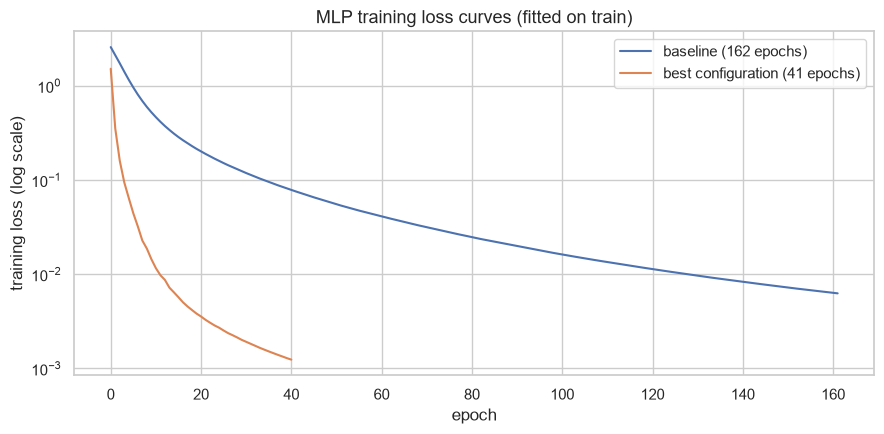

In [47]:
print("Selected MLP hyperparameters:", mlp_best_params)
mlp_best_validation = load_or_train("mlp_best_validation", make_mlp, mlp_best_params, X_train, y_train, idx_train)

display(pd.DataFrame({
    "baseline (validation)": mlp_baseline_val,
    "best configuration (validation)": evaluate_on_validation(mlp_best_validation),
}).round(4))

plt.figure(figsize=(9, 4.5))
for label, bundle in [("baseline", mlp_baseline), ("best configuration", mlp_best_validation)]:
    net = bundle["pipeline"].named_steps["classifier"]
    plt.plot(net.loss_curve_, label=f"{label} ({net.n_iter_} epochs)")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("training loss (log scale)")
plt.title("MLP training loss curves (fitted on train)", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

- Loss curves: the selected configuration converges in 41 epochs vs 162 for the baseline.

### 9.4 Final model (train + validation)

In [48]:
mlp_final = load_or_train("mlp_final", make_mlp, mlp_best_params, X_train_val, y_train_val, idx_train_val)
final_net = mlp_final["pipeline"].named_steps["classifier"]
print(f"Final MLP: {final_net.n_iter_} epochs, converged: {final_net.n_iter_ < final_net.max_iter}, "
      f"final training loss {final_net.loss_:.5f}")

[checkpoint] loaded checkpoints\mlp_final.joblib
  fitted on 1437 samples, training time 0.215s
Final MLP: 41 epochs, converged: True, final training loss 0.00097


### 9.5 Final test

=== MLP final — evaluation on the TEST set ===
Hyperparameters : {'hidden_layer_sizes': (100,), 'activation': 'relu', 'alpha': 0.0001, 'learning_rate_init': 0.01, 'max_iter': 200}
Trained on      : 1437 samples (train + validation)
Training time   : 0.2148 s | Prediction time (test): 0.0014 s
Test errors     : 7 / 360

Accuracy              0.9806
Precision Macro       0.9807
Recall Macro          0.9802
F1 Macro              0.9802
Precision Weighted    0.9807
Recall Weighted       0.9806
F1 Weighted           0.9804

--- Classification report (per class) ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        36
           1     0.9189    0.9444    0.9315        36
           2     1.0000    1.0000    1.0000        35
           3     0.9737    1.0000    0.9867        37
           4     0.9722    0.9722    0.9722        36
           5     1.0000    1.0000    1.0000        37
           6     1.0000    1.0000    1.0000        36


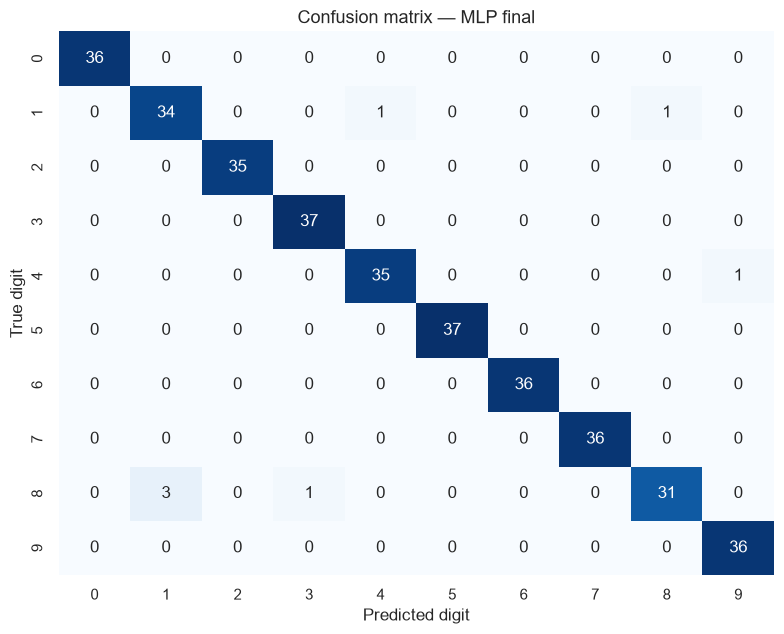

In [49]:
y_pred_mlp, mlp_test_metrics, mlp_pred_time = evaluate_on_test(mlp_final)
FINAL_RESULTS["MLP"] = {"bundle": mlp_final, "y_pred": y_pred_mlp,
                        "metrics": mlp_test_metrics, "pred_time": mlp_pred_time}

show_test_results("MLP final", mlp_final, y_pred_mlp, mlp_test_metrics, mlp_pred_time)
plot_confusion(y_test, y_pred_mlp, "Confusion matrix — MLP final")

Most frequent confusions (MLP):
 true digit  predicted digit  count
          8                1      3
          1                4      1
          1                8      1
          4                9      1
          8                3      1


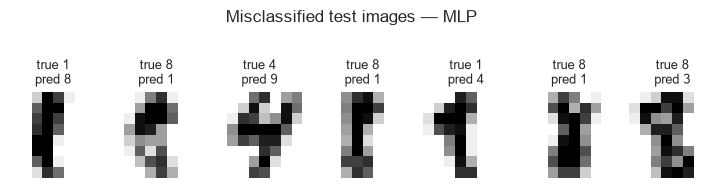

In [50]:
print("Most frequent confusions (MLP):")
print(top_confusions(y_test, y_pred_mlp).to_string(index=False))
show_misclassified(y_pred_mlp, "Misclassified test images — MLP")

- Accuracy **0.9806**, Macro F1 **0.9802**, 7 errors / 360.
- Main confusion: 8 → 1 (3 errors), as for KNN.

## 10. Final Comparison

- Test-set results of the three final models only.

### 10.1 Test-set performance

In [51]:
comparison = pd.DataFrame([
    {
        "Model": model,
        **result["metrics"],
        "Test errors": int((result["y_pred"] != y_test).sum()),
        "Training Time (s)": result["bundle"]["fit_time_s"],
        "Prediction Time (s)": result["pred_time"],
        "Best Parameters": result["bundle"]["params"],
    }
    for model, result in FINAL_RESULTS.items()
]).set_index("Model")

metric_columns = ["Accuracy", "Precision Macro", "Recall Macro", "F1 Macro",
                  "Precision Weighted", "Recall Weighted", "F1 Weighted"]
comparison.style.format({**{c: "{:.4f}" for c in metric_columns},
                         "Training Time (s)": "{:.4f}", "Prediction Time (s)": "{:.4f}"}) \
    .highlight_max(subset=metric_columns, color="lightgreen")

,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted,Test errors,Training Time (s),Prediction Time (s),Best Parameters
Model,,,,,,,,,,,
KNN,0.9861,0.9866,0.9859,0.9859,0.9867,0.9861,0.9861,5,0.0014,0.0040,"{'scaler': 'none', 'n_neighbors': 2, 'weights': 'distance'}"
SVM,0.9833,0.9839,0.9832,0.9832,0.9839,0.9833,0.9833,6,0.0312,0.0167,"{'kernel': 'rbf', 'C': 100.0, 'gamma': 0.01}"
MLP,0.9806,0.9807,0.9802,0.9802,0.9807,0.9806,0.9804,7,0.2148,0.0014,"{'hidden_layer_sizes': (100,), 'activation': 'relu', 'alpha': 0.0001, 'learning_rate_init': 0.01, 'max_iter': 200}"


- Training time: final fit on train + validation (measured when the checkpoint was created).
- Prediction time: the 360 test images. Both are hardware-dependent.

### 10.2 Visual comparison

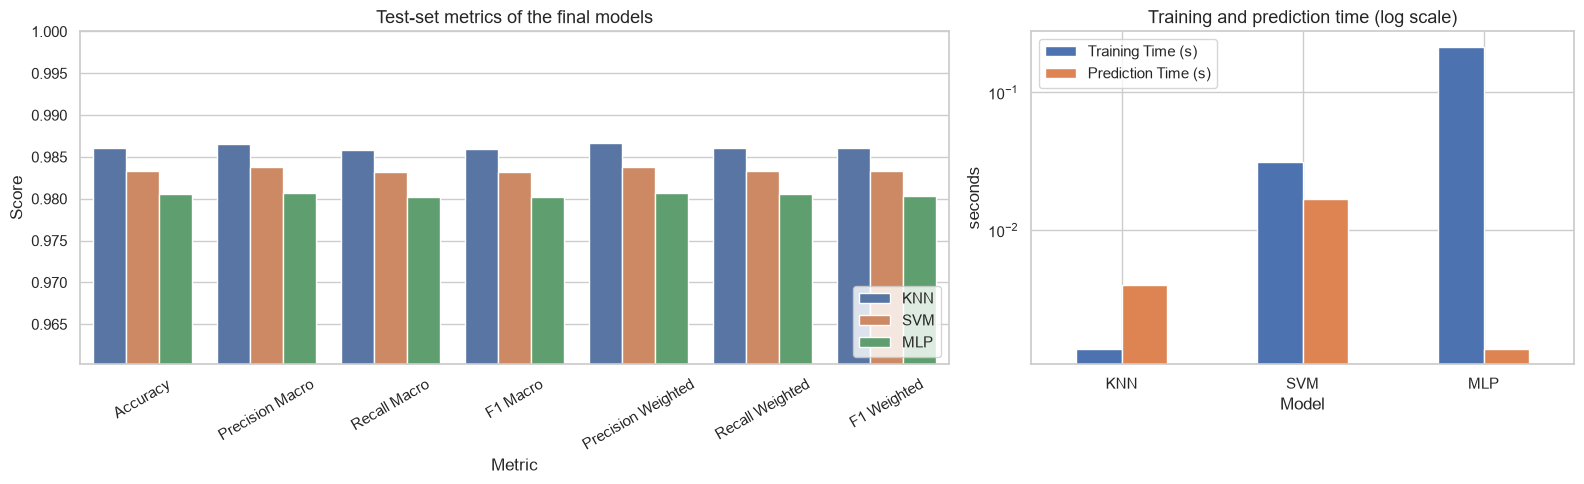

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1.6, 1]})

metrics_long = comparison[metric_columns].reset_index().melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=metrics_long, x="Metric", y="Score", hue="Model", ax=axes[0])
axes[0].set_ylim(max(0.0, metrics_long["Score"].min() - 0.02), 1.0)
axes[0].set_title("Test-set metrics of the final models", fontsize=13)
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(loc="lower right")

times = comparison[["Training Time (s)", "Prediction Time (s)"]]
times.plot(kind="bar", ax=axes[1], logy=True, rot=0)
axes[1].set_title("Training and prediction time (log scale)", fontsize=13)
axes[1].set_ylabel("seconds")
plt.tight_layout()
plt.show()

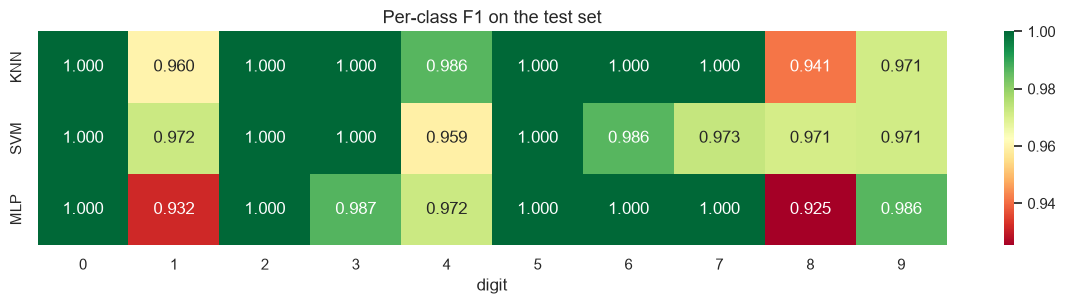

In [53]:
per_class_f1 = pd.DataFrame({
    model: f1_score(y_test, result["y_pred"], average=None, labels=range(10))
    for model, result in FINAL_RESULTS.items()
}, index=pd.Index(range(10), name="digit")).T

plt.figure(figsize=(12, 3.2))
sns.heatmap(per_class_f1, annot=True, fmt=".3f", cmap="RdYlGn", vmin=per_class_f1.values.min(), vmax=1.0)
plt.title("Per-class F1 on the test set", fontsize=13)
plt.tight_layout()
plt.show()

### 10.3 Validation vs test

- For information only; not used for any decision.

In [54]:
validation_vs_test = pd.DataFrame({
    "validation F1 macro (best config, fitted on train)": [
        evaluate_on_validation(knn_best_validation)["F1 Macro"],
        evaluate_on_validation(svm_best_validation)["F1 Macro"],
        evaluate_on_validation(mlp_best_validation)["F1 Macro"],
    ],
    "test F1 macro (final model, fitted on train + validation)": comparison["F1 Macro"].values,
}, index=comparison.index)
validation_vs_test["difference"] = validation_vs_test.iloc[:, 1] - validation_vs_test.iloc[:, 0]
validation_vs_test.round(4)

,"validation F1 macro (best config, fitted on train)","test F1 macro (final model, fitted on train + validation)",difference
Model,,,
KNN,0.9889,0.9859,-0.0030
SVM,0.9944,0.9832,-0.0112
MLP,0.9861,0.9802,-0.0058


### 10.4 Errors shared between classifiers

Test images misclassified by:
  exactly 0 model(s): 350
  exactly 1 model(s): 3
  exactly 2 model(s): 6
  exactly 3 model(s): 1

Pairwise overlap of errors (number of test images both models got wrong):
     KNN  SVM  MLP
KNN    5    2    3
SVM    2    6    4
MLP    3    4    7


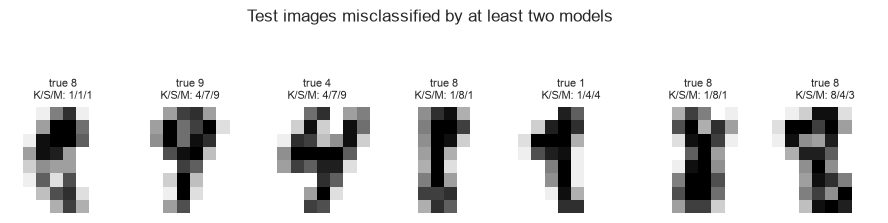

In [55]:
wrong = pd.DataFrame({model: result["y_pred"] != y_test for model, result in FINAL_RESULTS.items()})
n_models_wrong = wrong.sum(axis=1)

print("Test images misclassified by:")
for n in range(4):
    print(f"  exactly {n} model(s): {int((n_models_wrong == n).sum())}")
print("\nPairwise overlap of errors (number of test images both models got wrong):")
overlap = pd.DataFrame({a: [int((wrong[a] & wrong[b]).sum()) for b in wrong] for a in wrong}, index=wrong.columns)
print(overlap.to_string())

hard = np.flatnonzero(n_models_wrong >= 2)
if len(hard):
    fig, axes = plt.subplots(1, len(hard), figsize=(1.6 * len(hard), 2.3))
    for ax, i in zip(np.atleast_1d(axes), hard):
        ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r", interpolation="nearest")
        preds = "/".join(str(FINAL_RESULTS[m]["y_pred"][i]) for m in FINAL_RESULTS)
        ax.set_title(f"true {y_test[i]}\nK/S/M: {preds}", fontsize=8)
        ax.axis("off")
    plt.suptitle("Test images misclassified by at least two models", fontsize=12, y=1.15)
    plt.show()

- All three models achieved very similar results on this test split (5, 6 and 7 errors out of 360).
- KNN obtained the highest Accuracy and Macro F1 on this split; on validation the order was SVM > KNN > MLP.
- The differences correspond to one or two images, so these results alone do not show a substantial difference.
- Accuracy and Macro F1 are closely aligned (balanced classes).
- Digit 8 appears frequently in the observed confusions (8 → 1 for KNN and MLP).
- Errors largely overlap: 7 of the 10 misclassified images are missed by at least two models.
- Test scores are slightly below validation scores (−0.3 to −1.1 points), consistent with selecting the best
  configuration on validation.

## 11. Methodology Verification

- Programmatic checks of the protocol.

In [56]:
# Data, split, tuning and selection checks (1-4); model and checkpoint checks (5-8) follow in the next cell
checks = {}

# 1. 60 / 20 / 20 split
shares = np.array([len(y_train), len(y_val), len(y_test)]) / len(y)
checks["1. split is 60/20/20 (±1 pp)"] = bool(np.allclose(shares, [0.6, 0.2, 0.2], atol=0.01))

# 2. class proportions preserved by stratification
checks["2. class proportions preserved (max deviation < 1 pp)"] = bool(max_deviation < 1.0)

# 3. test set isolated: disjoint subsets and tuning results computed only from train/validation rows
disjoint = (len(np.intersect1d(idx_train, idx_val)) == 0 and len(np.intersect1d(idx_train, idx_test)) == 0
            and len(np.intersect1d(idx_val, idx_test)) == 0
            and len(idx_train) + len(idx_val) + len(idx_test) == len(y))
tuning_fp = f"{fingerprint(idx_train)}-{fingerprint(idx_val)}"
tuning_files = sorted(CHECKPOINT_DIR.glob("*_tuning_results.joblib"))
tuning_ok = len(tuning_files) > 0 and all(joblib.load(p)["data_fingerprint"] == tuning_fp for p in tuning_files)
checks["3. no test information used during tuning"] = bool(disjoint and tuning_ok)

# 4. hyperparameters chosen by the validation set: the final params are the top of the validation ranking
checks["4. hyperparameters = best validation F1 configuration"] = all(
    ranked.loc[0, "params"] == final["params"] and ranked.loc[0, "val_f1_macro"] == ranked["val_f1_macro"].max()
    for ranked, final in [(knn_ranked, knn_final), (svm_ranked, svm_final), (mlp_ranked, mlp_final)]
)
print("Checks 1-4 (data, split, tuning, selection) computed.")

Checks 1-4 (data, split, tuning, selection) computed.


In [ ]:
# 5. same observations for the three classifiers
development = [knn_baseline, knn_best_validation, svm_baseline, svm_best_validation, mlp_baseline, mlp_best_validation]
finals = [knn_final, svm_final, mlp_final]
checks["5. same train/validation/test rows for KNN, SVM and MLP"] = bool(
    all(b["data_fingerprint"] == fingerprint(idx_train) for b in development)
    and all(b["data_fingerprint"] == fingerprint(idx_trainval) for b in finals)
)

# 6. final models re-trained on train + validation
checks["6. final models fitted on train + validation"] = all(
    b["n_samples"] == len(y_train) + len(y_val) for b in finals
)

# 7. only the final models were evaluated on the test set, once each
checks["7. only final models evaluated on test (once each)"] = TEST_SET_LOG == ["knn_final", "svm_final", "mlp_final"]

# 8. checkpoints saved and reloadable, with identical predictions after reloading
expected = [f"{m}_{s}.joblib" for m in ["knn", "svm", "mlp"] for s in ["baseline", "best_validation", "final"]]
reload_ok = all(
    np.array_equal(joblib.load(CHECKPOINT_DIR / f"{b['name']}.joblib")["pipeline"].predict(X_val),
                   b["pipeline"].predict(X_val))
    for b in development + finals
)
checks["8. checkpoints saved and reload with identical predictions"] = bool(
    all((CHECKPOINT_DIR / f).exists() for f in expected) and reload_ok
)

verification = pd.Series(checks, name="passed").to_frame()
display(verification)
assert verification["passed"].all(), "At least one methodological check failed"
print("All methodological checks passed.")
print("Test-set access log:", TEST_SET_LOG)

,passed
1. split is 60/20/20 (±1 pp),True
2. class proportions preserved (max deviation < 1 pp),True
3. no test information used during tuning,True
4. hyperparameters = best validation F1 configuration,True
"5. same train/validation/test rows for KNN, SVM and MLP",True
6. final models fitted on train + validation,True
7. only final models evaluated on test (once each),True
8. checkpoints saved and reload with identical predictions,True


All methodological checks passed.
Test-set access log: ['knn_final', 'svm_final', 'mlp_final']


In [58]:
checkpoint_files = pd.DataFrame(
    [{"file": p.name, "size (KB)": round(p.stat().st_size / 1024, 1)} for p in sorted(CHECKPOINT_DIR.glob("*.joblib")) if not p.name.startswith("mnist_")]
)
checkpoint_files

,file,size (KB)
0,knn_baseline.joblib,549.9
1,knn_best_validation.joblib,548.1
2,knn_final.joblib,730.9
3,knn_tuning_results.joblib,8.8
4,mlp_baseline.joblib,247.6
5,mlp_best_validation.joblib,245.3
6,mlp_final.joblib,245.3
7,mlp_followup_tuning_results.joblib,3.0
8,mlp_tuning_results.joblib,4.8
9,svm_baseline.joblib,399.4


- 60/20/20 split; class proportions preserved.
- No test data used in tuning; final hyperparameters = best validation configuration.
- Same subsets for all models; final models trained on train + validation.
- Test set accessed only by final models, once each; checkpoints reload with identical predictions.

## 12. Conclusions

- KNN, SVM and MLP all achieved high performance (98.1–98.6 % test accuracy).
- KNN obtained the highest result on this particular split; the differences are one or two images.
- Accuracy and Macro F1 were closely aligned.
- Standardisation reduced KNN validation performance; the cause was not isolated.
- The MLP required a convergence check; the selected configuration uses a larger learning rate.
- Confusions involving digit 8 were frequent, consistent with the class-similarity analysis.
- Limitation: a single split with 360 validation and 360 test images; cross-validation would give more stable estimates.

## 13. Extra Work — MNIST

- Assignment: repeat the study on MNIST, explain why KNN becomes slow, include a convolutional classifier.
- Same protocol as Digits: stratified 60/20/20, selection on validation, retrain on train + validation, single test evaluation.
- Experiment sizes are chosen from measured costs.

### 13.1 MNIST Dataset Overview

- Source: `torchvision.datasets.MNIST`; the official 60 000 / 10 000 parts are pooled and re-split with the Digits protocol.
- Test scores are therefore not comparable with results on the official MNIST test split.

In [59]:
import gc
import random

import psutil
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.datasets import MNIST

MNIST_DATA_DIR = Path("data")
mnist_train_part = MNIST(MNIST_DATA_DIR, train=True, download=True)
mnist_test_part = MNIST(MNIST_DATA_DIR, train=False, download=True)

mnist_images = np.concatenate([mnist_train_part.data.numpy(), mnist_test_part.data.numpy()])
mnist_labels = np.concatenate([mnist_train_part.targets.numpy(), mnist_test_part.targets.numpy()])

print("torch:", torch.__version__, "| source: torchvision.datasets.MNIST")
print("Object type   :", type(mnist_train_part))
print("Official parts:", len(mnist_train_part), "train +", len(mnist_test_part), "test (pooled)")

mnist_overview = pd.Series({
    "number of images": len(mnist_images),
    "image array shape": mnist_images.shape,
    "pixel dtype": mnist_images.dtype,
    "image dimensions": mnist_images.shape[1:],
    "features after flattening": int(np.prod(mnist_images.shape[1:])),
    "number of classes": len(np.unique(mnist_labels)),
    "class values": np.unique(mnist_labels).tolist(),
}, name="value")
mnist_overview.to_frame()

torch: 2.14.0+cu130 | source: torchvision.datasets.MNIST
Object type   : <class 'torchvision.datasets.mnist.MNIST'>
Official parts: 60000 train + 10000 test (pooled)


,value
number of images,70000
image array shape,"(70000, 28, 28)"
pixel dtype,uint8
image dimensions,"(28, 28)"
features after flattening,784
number of classes,10
class values,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"


### 13.2 MNIST Exploratory Data Analysis

- Stored as uint8: NaN and infinity cannot occur; integrity is checked through dtype, shapes and value ranges.

In [60]:
mnist_flat_raw = mnist_images.reshape(len(mnist_images), -1)   # a view, no copy
row_keys = np.ascontiguousarray(mnist_flat_raw).view(np.dtype((np.void, mnist_flat_raw.shape[1]))).ravel()

mnist_integrity = pd.Series({
    "images / labels": f"{len(mnist_images)} / {len(mnist_labels)}",
    "image dtype / shape": f"{mnist_images.dtype} / {mnist_images.shape}",
    "label dtype / shape": f"{mnist_labels.dtype} / {mnist_labels.shape}",
    "every image is 28 × 28": mnist_images.shape[1:] == (28, 28),
    "min / max pixel value": f"{int(mnist_flat_raw.min())} / {int(mnist_flat_raw.max())}",
    "distinct labels": np.unique(mnist_labels).tolist(),
    "duplicated images": int(len(row_keys) - len(np.unique(row_keys))),
    "pixel positions that are 0 in every image": int((mnist_flat_raw.max(axis=0) == 0).sum()),
    "% of all pixel values equal to 0": round(100 * float((mnist_flat_raw == 0).mean()), 2),
}, name="result")
del row_keys
mnist_integrity.to_frame()

,result
images / labels,70000 / 70000
image dtype / shape,"uint8 / (70000, 28, 28)"
label dtype / shape,"int64 / (70000,)"
every image is 28 × 28,True
min / max pixel value,0 / 255
distinct labels,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
duplicated images,0
pixel positions that are 0 in every image,65
% of all pixel values equal to 0,80.86


digit                 0        1        2       3        4        5        6        7        8        9
count           6903.00  7877.00  6990.00  7141.0  6824.00  6313.00  6876.00  7293.00  6825.00  6958.00
percentage (%)     9.86    11.25     9.99    10.2     9.75     9.02     9.82    10.42     9.75     9.94

Smallest class: digit 5 (6313) | largest: digit 1 (7877) | imbalance ratio: 1.248


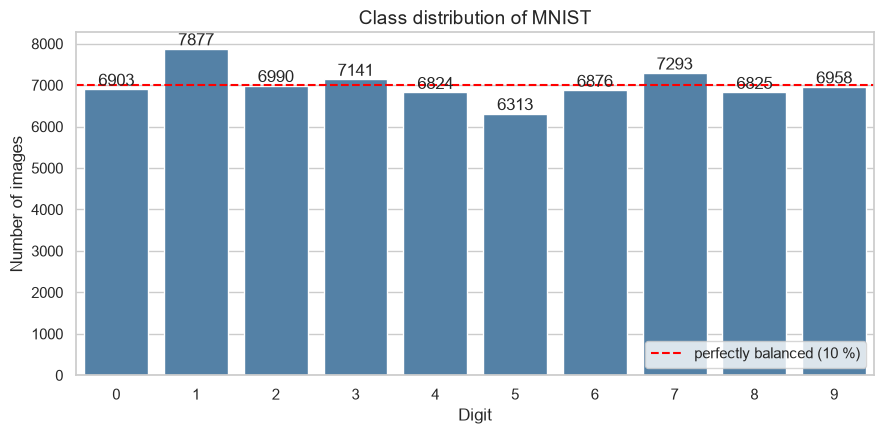

In [61]:
mnist_counts = pd.Series(mnist_labels).value_counts().sort_index()
mnist_class_distribution = pd.DataFrame({"count": mnist_counts, "percentage (%)": 100 * mnist_counts / len(mnist_labels)})
mnist_class_distribution.index.name = "digit"
print(mnist_class_distribution.T.round(2).to_string())
print(f"\nSmallest class: digit {mnist_counts.idxmin()} ({mnist_counts.min()}) | "
      f"largest: digit {mnist_counts.idxmax()} ({mnist_counts.max()}) | "
      f"imbalance ratio: {mnist_counts.max() / mnist_counts.min():.3f}")

plt.figure(figsize=(9, 4.5))
ax = sns.barplot(x=mnist_counts.index, y=mnist_counts.values, color="steelblue")
ax.axhline(len(mnist_labels) / 10, color="red", linestyle="--", label="perfectly balanced (10 %)")
ax.bar_label(ax.containers[0])
ax.set_xlabel("Digit")
ax.set_ylabel("Number of images")
ax.set_title("Class distribution of MNIST", fontsize=14)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

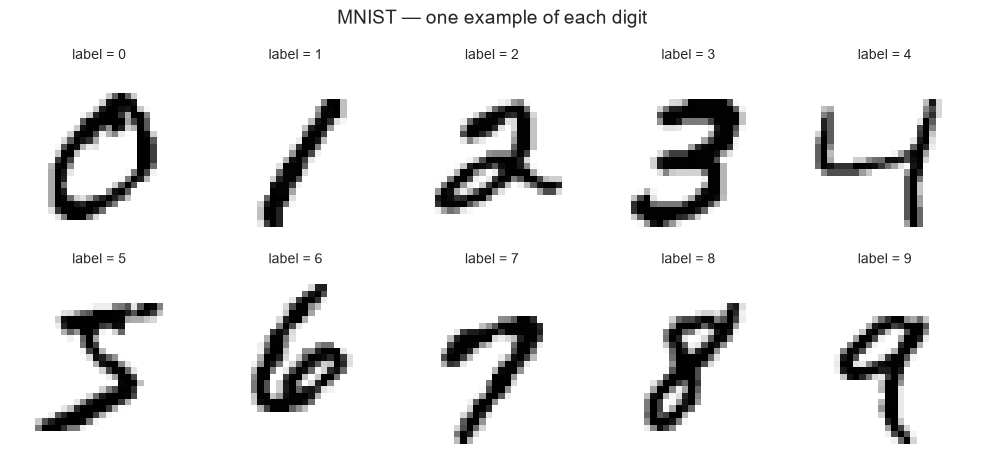

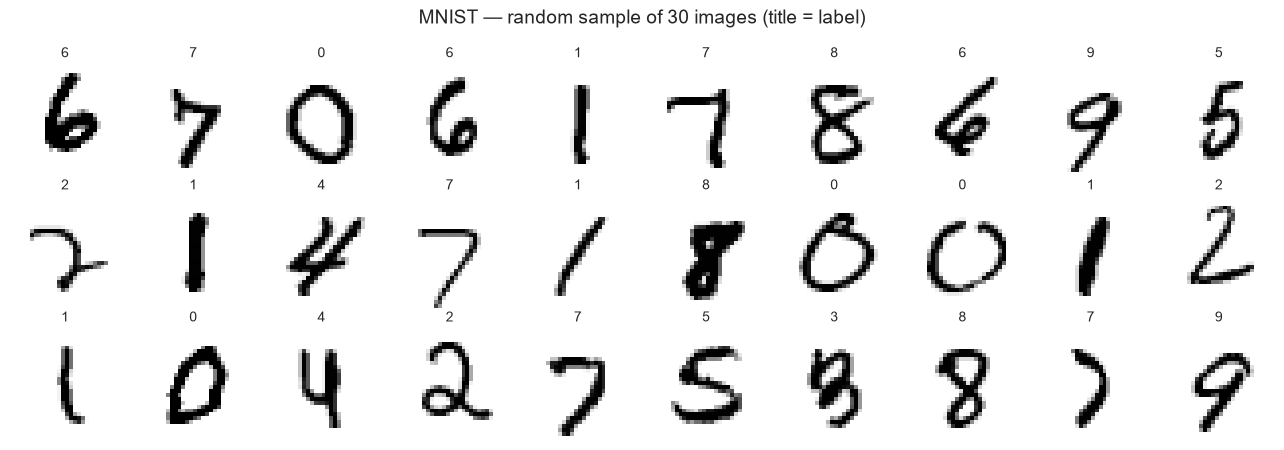

In [62]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.8))
for digit, ax in zip(range(10), axes.ravel()):
    idx = np.flatnonzero(mnist_labels == digit)[0]
    ax.imshow(mnist_images[idx], cmap="gray_r")
    ax.set_title(f"label = {digit}", fontsize=10)
    ax.axis("off")
plt.suptitle("MNIST — one example of each digit", fontsize=14)
plt.tight_layout()
plt.show()

rng = np.random.default_rng(RANDOM_STATE)
fig, axes = plt.subplots(3, 10, figsize=(13, 4.6))
for idx, ax in zip(rng.choice(len(mnist_labels), size=30, replace=False), axes.ravel()):
    ax.imshow(mnist_images[idx], cmap="gray_r")
    ax.set_title(str(mnist_labels[idx]), fontsize=10)
    ax.axis("off")
plt.suptitle("MNIST — random sample of 30 images (title = label)", fontsize=14)
plt.tight_layout()
plt.show()

In [63]:
def size_label(shape):
    return "×".join(str(s) for s in shape)

dataset_comparison = pd.DataFrame({
    "Digits": {
        "samples": len(digits.target),
        "image size": size_label(digits.images.shape[1:]),
        "features": digits.data.shape[1],
        "classes": len(np.unique(digits.target)),
        "pixel range": f"{digits.data.min():.0f}–{digits.data.max():.0f}",
        "samples per class": f"{np.bincount(digits.target).min()}–{np.bincount(digits.target).max()}",
    },
    "MNIST": {
        "samples": len(mnist_labels),
        "image size": size_label(mnist_images.shape[1:]),
        "features": mnist_flat_raw.shape[1],
        "classes": len(np.unique(mnist_labels)),
        "pixel range": f"{mnist_flat_raw.min()}–{mnist_flat_raw.max()}",
        "samples per class": f"{mnist_counts.min()}–{mnist_counts.max()}",
    },
})
print(f"MNIST has {len(mnist_labels) / len(digits.target):.1f}× more samples, "
      f"{mnist_flat_raw.shape[1] / digits.data.shape[1]:.2f}× more features and "
      f"{mnist_flat_raw.size / digits.data.size:.0f}× more pixel values than Digits.")
dataset_comparison

MNIST has 39.0× more samples, 12.25× more features and 477× more pixel values than Digits.


,Digits,MNIST
samples,1797,70000
image size,8×8,28×28
features,64,784
classes,10,10
pixel range,0–16,0–255
samples per class,174–183,6313–7877


- 70 000 images, 28×28 (784 features), 10 classes; pixels 0–255; no duplicates.
- Sparse: 80.9 % zeros; 65 border pixels are 0 in every image.
- Mildly imbalanced (6 313–7 877 per class, ratio 1.25) → stratification and Macro F1.
- 39× more samples and 12.25× more features than Digits.

### 13.3 MNIST Data Preparation

- Same stratified two-step split (`random_state=42`); indices saved to `checkpoints/mnist_split_indices.joblib`.
- All MNIST models use these indices.

In [64]:
mnist_ids = np.arange(len(mnist_labels))
mnist_idx_trainval, mnist_idx_test = train_test_split(
    mnist_ids, test_size=0.20, random_state=RANDOM_STATE, stratify=mnist_labels
)
mnist_idx_train, mnist_idx_val = train_test_split(
    mnist_idx_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=mnist_labels[mnist_idx_trainval]
)
mnist_idx_train_val = np.concatenate([mnist_idx_train, mnist_idx_val])

MNIST_SPLIT_PATH = CHECKPOINT_DIR / "mnist_split_indices.joblib"
mnist_split = {"train": mnist_idx_train, "validation": mnist_idx_val, "test": mnist_idx_test}
if MNIST_SPLIT_PATH.exists():
    saved_split = joblib.load(MNIST_SPLIT_PATH)
    assert all(np.array_equal(saved_split[k], v) for k, v in mnist_split.items()), "saved MNIST split differs"
    print(f"[checkpoint] recomputed split is identical to {MNIST_SPLIT_PATH}")
else:
    joblib.dump(mnist_split, MNIST_SPLIT_PATH)
    print(f"[checkpoint] saved split indices to {MNIST_SPLIT_PATH}")

mnist_proportions = pd.DataFrame({
    name: pd.Series(mnist_labels[ids]).value_counts(normalize=True).sort_index() * 100
    for name, ids in [("full dataset", mnist_ids), ("train", mnist_idx_train),
                      ("validation", mnist_idx_val), ("test", mnist_idx_test)]
})
mnist_max_deviation = (mnist_proportions[["train", "validation", "test"]]
                       .sub(mnist_proportions["full dataset"], axis=0).abs().max().max())

mnist_split_sizes = pd.DataFrame({"images": [len(mnist_idx_train), len(mnist_idx_val), len(mnist_idx_test)]},
                                 index=["train", "validation", "test"])
mnist_split_sizes["% of dataset"] = 100 * mnist_split_sizes["images"] / len(mnist_labels)
print(mnist_split_sizes.round(2).to_string())
print(f"\nLargest class-proportion deviation from the full dataset: {mnist_max_deviation:.3f} percentage points")

[checkpoint] recomputed split is identical to checkpoints\mnist_split_indices.joblib
            images  % of dataset
train        42000          60.0
validation   14000          20.0
test         14000          20.0

Largest class-proportion deviation from the full dataset: 0.004 percentage points


#### Input representation and scaling

- All models: pixels / 255 → [0, 1] (fixed transform, no leakage).
- KNN: scaling by a constant does not change the nearest neighbours.
- SVM / MLP: no `StandardScaler`; it would turn near-constant border pixels into extreme values (measured below).
- CNN: the same values as a 1×28×28 grid, converted per batch.
- Memory: only the uint8 images are kept in full; float32 features are built on demand (bit-identical, asserted).

In [ ]:
MNIST_INPUT = "pixels / 255 -> [0, 1], float32"   # stored in every MNIST checkpoint; changing it invalidates them
MNIST_N_FEATURES = int(np.prod(mnist_images.shape[1:]))


def mnist_features(ids):
    # float32 [0, 1] feature matrix of the given rows, built on demand (no full float copy of MNIST in RAM)
    return mnist_images[ids].reshape(len(ids), MNIST_N_FEATURES).astype(np.float32) / 255.0


def report_memory(label):
    info = psutil.Process().memory_info()
    peak = getattr(info, "peak_wset", None)   
    print(f"[memory] {label}: current {info.rss / 2**20:,.0f} MB"
          + (f" | peak so far {peak / 2**20:,.0f} MB" if peak is not None else ""))


Xm_train, ym_train = mnist_features(mnist_idx_train), mnist_labels[mnist_idx_train]
Xm_val, ym_val = mnist_features(mnist_idx_val), mnist_labels[mnist_idx_val]
Xm_test, ym_test = mnist_features(mnist_idx_test), mnist_labels[mnist_idx_test]
ym_train_val = mnist_labels[mnist_idx_train_val]   

pd.DataFrame({"features (KNN / SVM / MLP)": [Xm_train.shape, Xm_val.shape, Xm_test.shape],
              "CNN input per batch": ["(batch, 1, 28, 28)"] * 3}, index=["train", "validation", "test"])

,features (KNN / SVM / MLP),CNN input per batch
train,"(42000, 784)","(batch, 1, 28, 28)"
validation,"(14000, 784)","(batch, 1, 28, 28)"
test,"(14000, 784)","(batch, 1, 28, 28)"


In [66]:
report_memory("after building the train / validation / test feature matrices")

[memory] after building the train / validation / test feature matrices: current 1,097 MB | peak so far 1,139 MB


In [67]:
train_std_m = Xm_train.std(axis=0)
nonzero_std = train_std_m > 0
z_max = (np.abs(Xm_train[:, nonzero_std] - Xm_train[:, nonzero_std].mean(axis=0)) / train_std_m[nonzero_std]).max(axis=0)
print(f"Zero-variance pixels in train: {int((~nonzero_std).sum())} of {Xm_train.shape[1]}")
print(f"Pixels with std < 0.01 (almost always 0): {int((nonzero_std & (train_std_m < 0.01)).sum())}")
print(f"If standardised: max |z| over pixels = {z_max.max():.0f} "
      f"(median pixel: {np.median(z_max):.1f}) -> StandardScaler would create extreme inputs")

Zero-variance pixels in train: 76 of 784
Pixels with std < 0.01 (almost always 0): 85
If standardised: max |z| over pixels = 205 (median pixel: 4.9) -> StandardScaler would create extreme inputs


#### Evaluation helpers

- The Digits helpers are reused; `mnist_evaluate_on_test` is the only (logged) access to the MNIST test set.

In [ ]:
def stratified_subset(ids, n):
    if n >= len(ids):
        return ids
    subset, _ = train_test_split(ids, train_size=n, random_state=RANDOM_STATE, stratify=mnist_labels[ids])
    return subset


MNIST_TEST_LOG = []   
MNIST_FINAL = {}      


def mnist_evaluate_on_test(name, predict_fn):
    if not name.endswith("_final"):
        raise ValueError(f"{name} is not a final model: the test set is reserved for final models.")
    MNIST_TEST_LOG.append(name)
    start = time.perf_counter()
    y_pred = np.asarray(predict_fn())
    pred_time = time.perf_counter() - start
    return y_pred, compute_metrics(ym_test, y_pred), pred_time


def mnist_report(model_label, result):
    print_test_report(f"{model_label} — evaluation on the MNIST TEST set", ym_test, result["y_pred"], result["metrics"], {
        "Hyperparameters": result["params"],
        "Training time": f"{result['fit_time']:.2f} s | Prediction time ({len(ym_test)} images): {result['pred_time']:.2f} s",
    })
    plot_confusion(ym_test, result["y_pred"], f"Confusion matrix — {model_label} (MNIST test)")
    pairs = top_confusions(ym_test, result["y_pred"])
    print("Most frequent confusions (true→predicted):",
          ", ".join(f"{t}→{p} ({n})" for t, p, n in pairs.itertuples(index=False)))

### 13.4 KNN Scalability Analysis

- KNN is a lazy learner: `fit` only stores the data; most cost occurs during inference.
- Cost per query ≈ n_train × n_features.
- MNIST has substantially more samples and features than Digits:

In [69]:
knn_cost = pd.DataFrame({
    "Digits": {"training images (final model)": len(y_train_val), "features": X.shape[1], "test queries": len(y_test)},
    "MNIST": {"training images (final model)": len(mnist_idx_train_val), "features": MNIST_N_FEATURES,
              "test queries": len(mnist_idx_test)},
}).T
knn_cost["distance operations per query (n × d)"] = knn_cost["training images (final model)"] * knn_cost["features"]
knn_cost["operations for the whole test set"] = knn_cost["distance operations per query (n × d)"] * knn_cost["test queries"]
cost_ratio = knn_cost.loc["MNIST"] / knn_cost.loc["Digits"]
print(f"Per query, MNIST needs ~{cost_ratio['distance operations per query (n × d)']:.0f}× more operations than Digits; "
      f"for the whole test set ~{cost_ratio['operations for the whole test set']:,.0f}× more.")
knn_cost

Per query, MNIST needs ~477× more operations than Digits; for the whole test set ~18,565× more.


,training images (final model),features,test queries,distance operations per query (n × d),operations for the whole test set
Digits,1437,64,360,91968,33108480
MNIST,56000,784,14000,43904000,614656000000


#### Benchmark

- KNN (`k=5`) on stratified training subsets of 1 000 → 42 000 images.
- Prediction timed on the same 2 000 validation images (best of 3).

In [70]:
KNN_BENCH_SIZES = [1000, 5000, 10000, 20000, len(mnist_idx_train)]
KNN_BENCH_QUERIES = 2000
KNN_BENCH_REPEATS = 3
knn_bench_queries = stratified_subset(mnist_idx_val, KNN_BENCH_QUERIES)

bench_key = {"sizes": KNN_BENCH_SIZES, "repeats": KNN_BENCH_REPEATS, "input": MNIST_INPUT,
             "train": fingerprint(mnist_idx_train), "queries": fingerprint(knn_bench_queries)}


def run_knn_benchmark():
    X_bench_queries = mnist_features(knn_bench_queries)
    rows = []
    for n in KNN_BENCH_SIZES:
        ids = stratified_subset(mnist_idx_train, n)
        X_bench_train = mnist_features(ids)
        fit_times, predict_times = [], []
        for _ in range(KNN_BENCH_REPEATS):
            knn = KNeighborsClassifier(n_neighbors=5)
            start = time.perf_counter()
            knn.fit(X_bench_train, mnist_labels[ids])
            fit_times.append(time.perf_counter() - start)
            start = time.perf_counter()
            y_bench_pred = knn.predict(X_bench_queries)
            predict_times.append(time.perf_counter() - start)
        rows.append({
            "Training samples": len(ids), "Features": MNIST_N_FEATURES,
            "Fit time (s)": min(fit_times), "Prediction time (s)": min(predict_times),
            "Prediction time per query (ms)": 1000 * min(predict_times) / KNN_BENCH_QUERIES,
            "Accuracy": accuracy_score(mnist_labels[knn_bench_queries], y_bench_pred),
            "F1 Macro": f1_score(mnist_labels[knn_bench_queries], y_bench_pred, average="macro"),
        })
        print(f"  n = {len(ids):>6}: prediction {min(predict_times):.3f}s")
    return pd.DataFrame(rows)


knn_bench = load_or_compute(CHECKPOINT_DIR / "mnist_knn_scalability_benchmark.joblib", {"key": bench_key},
                            run_knn_benchmark, value_key="results")
knn_bench.round(4)

[checkpoint] loaded checkpoints\mnist_knn_scalability_benchmark.joblib


,Training samples,Features,Fit time (s),Prediction time (s),Prediction time per query (ms),Accuracy,F1 Macro
0,1000,784,0.0028,0.0547,0.0274,0.8790,0.8780
1,5000,784,0.0142,0.1755,0.0877,0.9280,0.9273
2,10000,784,0.0202,0.2894,0.1447,0.9395,0.9388
3,20000,784,0.0446,0.5514,0.2757,0.9540,0.9540
4,42000,784,0.0814,1.0337,0.5169,0.9640,0.9639


Digits reference (same classifier, Digits validation set):

In [71]:
digits_knn_ref = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
digits_times = []
for _ in range(KNN_BENCH_REPEATS):
    start = time.perf_counter()
    digits_knn_ref.predict(X_val)
    digits_times.append(time.perf_counter() - start)
digits_ms_per_query = 1000 * min(digits_times) / len(X_val)
mnist_ms_per_query = knn_bench["Prediction time per query (ms)"].iloc[-1]
print(f"Digits reference ({len(y_train)} training images × {X_train.shape[1]} features): "
      f"{digits_ms_per_query:.4f} ms per query")
print(f"MNIST ({knn_bench['Training samples'].iloc[-1]} training images × {MNIST_N_FEATURES} features): "
      f"{mnist_ms_per_query:.4f} ms per query  ->  {mnist_ms_per_query / digits_ms_per_query:.0f}× slower per query")

Digits reference (1077 training images × 64 features): 0.0409 ms per query
MNIST (42000 training images × 784 features): 0.5169 ms per query  ->  13× slower per query


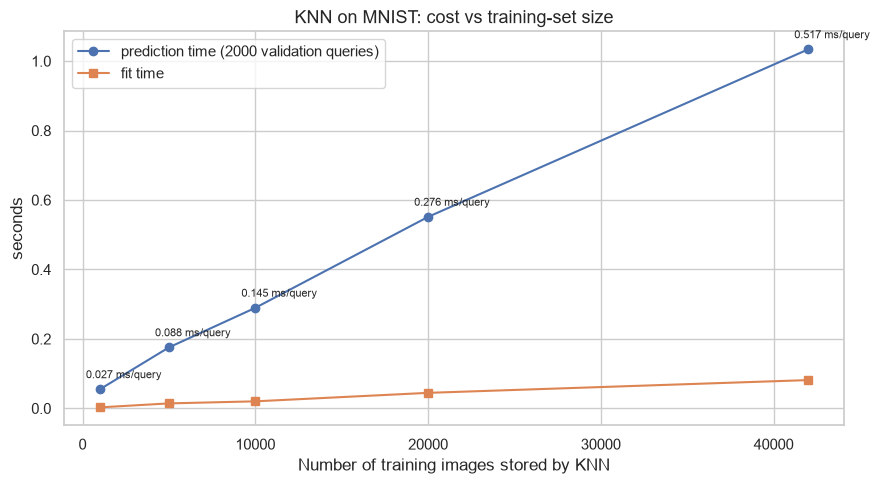

Training set ×42 -> prediction time ×18.9
Linear fit of prediction time: 23.7 ms per extra 1000 training images (2000 queries), R² = 0.998


In [72]:
slope, intercept = np.polyfit(knn_bench["Training samples"], knn_bench["Prediction time (s)"], 1)
fitted = slope * knn_bench["Training samples"] + intercept
r2 = 1 - ((knn_bench["Prediction time (s)"] - fitted) ** 2).sum() / \
    ((knn_bench["Prediction time (s)"] - knn_bench["Prediction time (s)"].mean()) ** 2).sum()

plt.figure(figsize=(9, 5))
plt.plot(knn_bench["Training samples"], knn_bench["Prediction time (s)"], marker="o",
         label=f"prediction time ({KNN_BENCH_QUERIES} validation queries)")
plt.plot(knn_bench["Training samples"], knn_bench["Fit time (s)"], marker="s", label="fit time")
for n, t, ms in knn_bench[["Training samples", "Prediction time (s)", "Prediction time per query (ms)"]].values:
    plt.annotate(f"{ms:.3f} ms/query", (n, t), textcoords="offset points", xytext=(-10, 8), fontsize=8)
plt.xlabel("Number of training images stored by KNN")
plt.ylabel("seconds")
plt.title("KNN on MNIST: cost vs training-set size", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

size_ratio = knn_bench["Training samples"].iloc[-1] / knn_bench["Training samples"].iloc[0]
time_ratio = knn_bench["Prediction time (s)"].iloc[-1] / knn_bench["Prediction time (s)"].iloc[0]
print(f"Training set ×{size_ratio:.0f} -> prediction time ×{time_ratio:.1f}")
print(f"Linear fit of prediction time: {1e6 * slope:.1f} ms per extra 1000 training images "
      f"({KNN_BENCH_QUERIES} queries), R² = {r2:.3f}")

- Prediction time increased as the training set grew: 0.055 s → 1.03 s for 2 000 queries, close to linear (R² = 0.998).
- Fit time stays below 0.1 s; accuracy also increased with more stored images (0.88 → 0.96).
- Per query, MNIST is 21× more expensive than Digits (below the ≈ 480× operation-count ratio; fixed overheads may
  contribute, not measured).
- Full MNIST KNN remained feasible on this hardware (≈ 8 s for 14 000 test images), but inference became
  substantially more expensive.

#### Decision: run KNN on the full training set?

- Validation-pass time projected from the measured per-query cost; if within budget, a small tuning (`k`, `weights`)
  is run on the full training set.

In [73]:
KNN_TIME_BUDGET_S = 120   # acceptable time for one prediction pass over the validation set
projected_val_pass = mnist_ms_per_query / 1000 * len(mnist_idx_val)
run_full_knn = bool(projected_val_pass <= KNN_TIME_BUDGET_S)
print(f"Projected time to predict the {len(mnist_idx_val)} validation images with the full training set: "
      f"{projected_val_pass:.1f} s (budget {KNN_TIME_BUDGET_S} s) -> run full KNN: {run_full_knn}")

Projected time to predict the 14000 validation images with the full training set: 7.2 s (budget 120 s) -> run full KNN: True


In [74]:
def make_mnist_knn(input_version, **knn_params):
    # input_version is only recorded with the results (inputs are already scaled)
    return Pipeline([("classifier", KNeighborsClassifier(**knn_params))])


if run_full_knn:
    mnist_knn_candidates = [{"input_version": MNIST_INPUT, "n_neighbors": k, "weights": w}
                            for w in ["uniform", "distance"] for k in [1, 3, 5, 7]]
    mnist_knn_results = run_tuning("mnist_knn_tuning", make_mnist_knn, mnist_knn_candidates,
                                   Xm_train, ym_train, mnist_idx_train, Xm_val, ym_val, mnist_idx_val, verbose=True)
    mnist_knn_best_params, mnist_knn_ranked = select_best(
        mnist_knn_results, tie_breakers=[("val_accuracy", False), ("n_neighbors", False)])
    print("Selected KNN hyperparameters:", mnist_knn_best_params)
    display(mnist_knn_ranked[["weights", "n_neighbors", "val_accuracy", "val_f1_macro", "val_predict_time_s"]])
else:
    print("KNN is not run on the full training set; it is reported as a scalability benchmark only.")

[checkpoint] loaded checkpoints\mnist_knn_tuning.joblib
  8 configurations: fitted on 42000 training rows, scored on 14000 validation rows
Selected KNN hyperparameters: {'input_version': 'pixels / 255 -> [0, 1], float32', 'n_neighbors': 3, 'weights': 'distance'}


,weights,n_neighbors,val_accuracy,val_f1_macro,val_predict_time_s
0,distance,3,0.9714,0.9713,6.6288
1,uniform,3,0.9704,0.9703,7.3091
2,distance,7,0.9699,0.9700,7.6997
3,distance,5,0.9699,0.9699,6.5676
4,uniform,1,0.9699,0.9697,7.4061
5,distance,1,0.9699,0.9697,6.4749
6,uniform,7,0.9689,0.9689,6.8343
7,uniform,5,0.9684,0.9684,6.5721


- Final KNN refit on train + validation and evaluated once on test.
- Not checkpointed: the "model" is the training data itself.

=== KNN final — evaluation on the MNIST TEST set ===
Hyperparameters : {'n_neighbors': 3, 'weights': 'distance'}
Training time   : 0.03 s | Prediction time (14000 images): 12.17 s
Test errors     : 375 / 14000

Accuracy              0.9732
Precision Macro       0.9736
Recall Macro          0.9728
F1 Macro              0.9731
Precision Weighted    0.9734
Recall Weighted       0.9732
F1 Weighted           0.9732

--- Classification report (per class) ---
              precision    recall  f1-score   support

           0     0.9773    0.9964    0.9867      1381
           1     0.9643    0.9937    0.9787      1575
           2     0.9890    0.9621    0.9753      1398
           3     0.9747    0.9720    0.9734      1428
           4     0.9842    0.9575    0.9707      1365
           5     0.9682    0.9644    0.9663      1263
           6     0.9755    0.9862    0.9808      1375
           7     0.9649    0.9801    0.9725      1459
           8     0.9863    0.9473    0.9664      1365
  

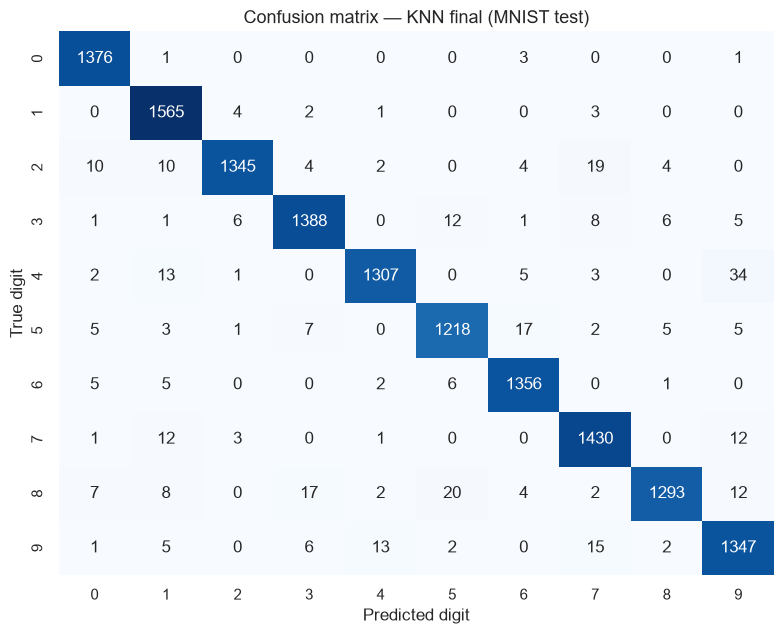

Most frequent confusions (true→predicted): 4→9 (34), 8→5 (20), 2→7 (19), 5→6 (17), 8→3 (17), 9→7 (15)


In [75]:
if run_full_knn:
    Xm_train_val = np.concatenate([Xm_train, Xm_val])   # same row order as mnist_idx_train_val
    mnist_knn_final = make_mnist_knn(**mnist_knn_best_params)
    knn_fit_time, _ = fit_with_timing(mnist_knn_final, Xm_train_val, ym_train_val)
    y_pred, metrics, pred_time = mnist_evaluate_on_test("mnist_knn_final", lambda: mnist_knn_final.predict(Xm_test))
    MNIST_FINAL["KNN"] = {"y_pred": y_pred, "metrics": metrics, "pred_time": pred_time, "fit_time": knn_fit_time,
                          "params": {k: v for k, v in mnist_knn_best_params.items() if k != "input_version"},
                          "notes": "lazy learner: fit only stores 56 000 images; cost is at prediction time"}
    mnist_report("KNN final", MNIST_FINAL["KNN"])

*Memory:* fitted KNN and train + validation matrix released.

In [76]:
if run_full_knn:
    del mnist_knn_final, Xm_train_val, y_pred
del digits_knn_ref
gc.collect()
report_memory("after KNN (fitted model and train + validation matrix released)")

[memory] after KNN (fitted model and train + validation matrix released): current 883 MB | peak so far 1,184 MB


- Projected validation pass: 7.2 s (within budget), so KNN was run on the full data.
- Best: `k=3`, distance weights — validation Macro F1 **0.9713**.
- Test: Accuracy **0.9732**, Macro F1 **0.9731**, 375 errors; main confusion 4 → 9 (34).
- Test prediction ≈ 8 s vs 0.02 s fit.

### 13.5 SVM on MNIST

- `SVC` training cost grows steeply with the number of samples; it is measured first on small subsets.

In [77]:
SVM_PROBE_SIZES = [2500, 5000, 10000]
probe_key = {"sizes": SVM_PROBE_SIZES, "input": MNIST_INPUT, "train": fingerprint(mnist_idx_train)}


def run_svm_probe():
    rows = []
    for n in SVM_PROBE_SIZES:
        ids = stratified_subset(mnist_idx_train, n)
        X_probe = mnist_features(ids)
        probe_svm = SVC(random_state=RANDOM_STATE)
        start = time.perf_counter()
        probe_svm.fit(X_probe, mnist_labels[ids])
        rows.append({"training samples": n, "fit time (s)": time.perf_counter() - start,
                     "support vectors": int(probe_svm.n_support_.sum())})
    return pd.DataFrame(rows)


svm_probe = load_or_compute(CHECKPOINT_DIR / "mnist_svm_cost_probe.joblib", {"key": probe_key}, run_svm_probe,
                            value_key="results")

exponent, log_coef = np.polyfit(np.log(svm_probe["training samples"]), np.log(svm_probe["fit time (s)"]), 1)


def estimated_svm_fit_time(n):
    return np.exp(log_coef) * n ** exponent


display(svm_probe.round(3))
print(f"Empirical scaling of the fit time: ~ n^{exponent:.2f}")
print(f"Estimated fit time of ONE configuration on the full training set ({len(mnist_idx_train)} images): "
      f"{estimated_svm_fit_time(len(mnist_idx_train)):.0f} s; on train + validation ({len(mnist_idx_train_val)}): "
      f"{estimated_svm_fit_time(len(mnist_idx_train_val)):.0f} s")

[checkpoint] loaded checkpoints\mnist_svm_cost_probe.joblib


,training samples,fit time (s),support vectors
0,2500,0.413,1500
1,5000,1.219,2459
2,10000,7.270,3903


Empirical scaling of the fit time: ~ n^2.07
Estimated fit time of ONE configuration on the full training set (42000 images): 126 s; on train + validation (56000): 228 s


- Tuning on a **stratified 10 000-image training subset** (computational reasons), scored on the full validation set.
- Grid: RBF, `C` ∈ {1, 10}, `gamma` ∈ {scale, 0.05}.
- The selected configuration is retrained on the full train + validation set (56 000 images).
- Limitation: the best `C` / `gamma` on 10 000 images may differ on 56 000.

In [78]:
SVM_TUNING_SIZE = 10000
svm_tuning_ids = stratified_subset(mnist_idx_train, SVM_TUNING_SIZE)
X_svm_subset = mnist_features(svm_tuning_ids)


def make_mnist_svm(input_version, **svm_params):
    # input_version is only recorded with the checkpoint (inputs are already scaled)
    return Pipeline([("classifier", SVC(random_state=RANDOM_STATE, **svm_params))])


mnist_svm_baseline_params = {"input_version": MNIST_INPUT, "kernel": "rbf", "C": 1.0, "gamma": "scale"}
mnist_svm_baseline = load_or_train("mnist_svm_baseline", make_mnist_svm, mnist_svm_baseline_params,
                                   X_svm_subset, mnist_labels[svm_tuning_ids], svm_tuning_ids)
print("Baseline validation metrics:",
      {k: round(v, 4) for k, v in compute_metrics(ym_val, mnist_svm_baseline["pipeline"].predict(Xm_val)).items()
       if k in ("Accuracy", "F1 Macro")})

mnist_svm_candidates = [{"input_version": MNIST_INPUT, "kernel": "rbf", "C": C, "gamma": gamma}
                        for C in [1.0, 10.0] for gamma in ["scale", 0.05]]
mnist_svm_results = run_tuning("mnist_svm_tuning", make_mnist_svm, mnist_svm_candidates,
                               X_svm_subset, mnist_labels[svm_tuning_ids], svm_tuning_ids, Xm_val, ym_val, mnist_idx_val,
                               extra_info=svm_extra_info, verbose=True)
mnist_svm_best_params, mnist_svm_ranked = select_best(
    mnist_svm_results, tie_breakers=[("val_accuracy", False), ("n_support_vectors", True), ("C", True)])
print("Selected SVM hyperparameters:", mnist_svm_best_params)
mnist_svm_ranked[["C", "gamma", "val_accuracy", "val_f1_macro", "n_support_vectors", "fit_time_s", "val_predict_time_s"]]

[checkpoint] loaded checkpoints\mnist_svm_baseline.joblib
  fitted on 10000 samples, training time 7.069s
Baseline validation metrics: {'Accuracy': 0.9599, 'F1 Macro': 0.9596}
[checkpoint] loaded checkpoints\mnist_svm_tuning.joblib
  4 configurations: fitted on 10000 training rows, scored on 14000 validation rows
Selected SVM hyperparameters: {'input_version': 'pixels / 255 -> [0, 1], float32', 'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'}


,C,gamma,val_accuracy,val_f1_macro,n_support_vectors,fit_time_s,val_predict_time_s
0,10.0,scale,0.9674,0.9672,3768,6.4250,24.3379
1,10.0,0.05,0.9656,0.9655,6345,25.6771,41.5437
2,1.0,0.05,0.9641,0.9639,6299,24.7502,43.5486
3,1.0,scale,0.9599,0.9596,3903,9.8842,27.0798


- Fit time grows ≈ n^2.07 (≈ 2 min estimated per configuration on the full training set).
- Best: `C=10`, `gamma="scale"` — validation Macro F1 **0.9672** (baseline 0.9596).
- `gamma=0.05` needed more support vectors and time without improving the score.

[checkpoint] loaded checkpoints\mnist_svm_best_validation.joblib
  fitted on 10000 samples, training time 6.767s
[checkpoint] loaded checkpoints\mnist_svm_final.joblib
  fitted on 56000 samples, training time 152.189s
Support vectors of the final SVM: 10972
=== SVM final — evaluation on the MNIST TEST set ===
Hyperparameters : {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'}
Training time   : 152.19 s | Prediction time (14000 images): 76.92 s
Test errors     : 232 / 14000

Accuracy              0.9834
Precision Macro       0.9834
Recall Macro          0.9833
F1 Macro              0.9833
Precision Weighted    0.9834
Recall Weighted       0.9834
F1 Weighted           0.9834

--- Classification report (per class) ---
              precision    recall  f1-score   support

           0     0.9829    0.9971    0.9899      1381
           1     0.9867    0.9911    0.9889      1575
           2     0.9828    0.9828    0.9828      1398
           3     0.9866    0.9797    0.9831      1428
       

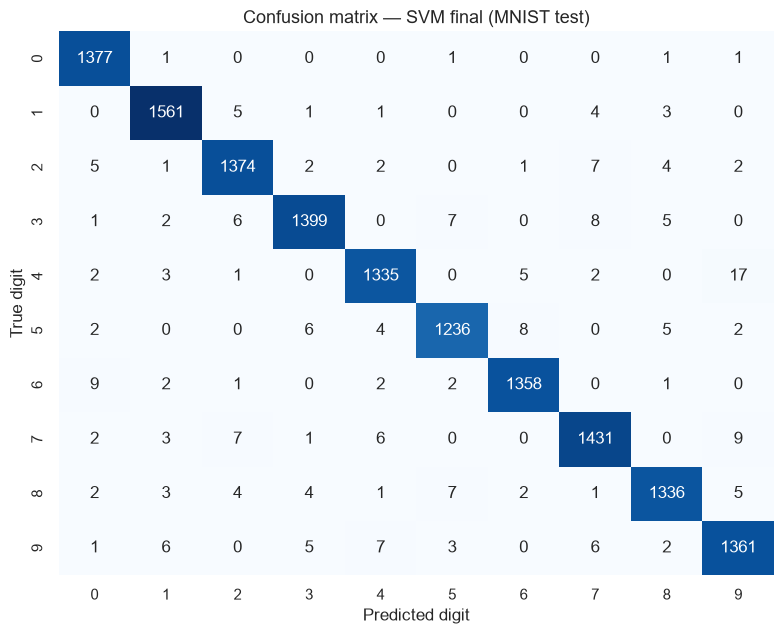

Most frequent confusions (true→predicted): 4→9 (17), 6→0 (9), 7→9 (9), 3→7 (8), 5→6 (8), 2→7 (7)


In [79]:
mnist_svm_best_validation = load_or_train("mnist_svm_best_validation", make_mnist_svm, mnist_svm_best_params,
                                          X_svm_subset, mnist_labels[svm_tuning_ids], svm_tuning_ids)
Xm_train_val = np.concatenate([Xm_train, Xm_val])   # same row order as mnist_idx_train_val
mnist_svm_final = load_or_train("mnist_svm_final", make_mnist_svm, mnist_svm_best_params,
                                Xm_train_val, ym_train_val, mnist_idx_train_val)
print(f"Support vectors of the final SVM: {mnist_svm_final['pipeline'].named_steps['classifier'].n_support_.sum()}")

y_pred, metrics, pred_time = mnist_evaluate_on_test("mnist_svm_final",
                                                    lambda: mnist_svm_final["pipeline"].predict(Xm_test))
MNIST_FINAL["SVM"] = {"y_pred": y_pred, "metrics": metrics, "pred_time": pred_time,
                      "fit_time": mnist_svm_final["fit_time_s"],
                      "params": {k: v for k, v in mnist_svm_best_params.items() if k != "input_version"},
                      "notes": f"C/gamma chosen on a {SVM_TUNING_SIZE}-image training subset; final fit on 56 000"}
mnist_report("SVM final", MNIST_FINAL["SVM"])

- Test: Accuracy **0.9834**, Macro F1 **0.9833**, 232 errors; main confusion 4 → 9 (17).
- Most expensive model: 152 s training, 74 s prediction (10 972 support vectors).

*Memory:* fitted SVMs and temporary matrices released.

In [80]:
MNIST_BUNDLE_INFO = {}   # checkpoint metadata kept for the verification, without the fitted models


def keep_bundle_info(*bundles):
    for bundle in bundles:
        MNIST_BUNDLE_INFO[bundle["name"]] = {k: v for k, v in bundle.items() if k != "pipeline"}


keep_bundle_info(mnist_svm_baseline, mnist_svm_best_validation, mnist_svm_final)
del mnist_svm_baseline, mnist_svm_best_validation, mnist_svm_final, X_svm_subset, Xm_train_val, y_pred
gc.collect()
report_memory("after SVM (fitted SVMs and temporary matrices released)")

[memory] after SVM (fitted SVMs and temporary matrices released): current 885 MB | peak so far 1,278 MB


### 13.6 MLP on MNIST

- Full training set; inputs in [0, 1].
- Step 1: architecture `(100,)`, `(256,)`, `(256, 128)`; step 2: `alpha` ∈ {1e-3, 1e-2} on the best architecture.
- `max_iter=200`; ConvergenceWarnings are recorded.

In [81]:
def make_mnist_mlp(input_version, **mlp_params):
    # input_version is only recorded with the checkpoint (inputs are already scaled)
    return Pipeline([("classifier", MLPClassifier(random_state=RANDOM_STATE, **mlp_params))])


def mnist_mlp_params(hidden=(100,), alpha=1e-4, lr=1e-3, max_iter=200):
    return {"input_version": MNIST_INPUT, "hidden_layer_sizes": hidden, "activation": "relu",
            "alpha": alpha, "learning_rate_init": lr, "max_iter": max_iter}


mnist_mlp_baseline = load_or_train("mnist_mlp_baseline", make_mnist_mlp, mnist_mlp_params(),
                                   Xm_train, ym_train, mnist_idx_train)
net = mnist_mlp_baseline["pipeline"].named_steps["classifier"]
print(f"Baseline: {net.n_iter_} epochs (converged: {net.n_iter_ < net.max_iter}) | validation metrics:",
      {k: round(v, 4) for k, v in compute_metrics(ym_val, mnist_mlp_baseline["pipeline"].predict(Xm_val)).items()
       if k in ("Accuracy", "F1 Macro")})

mlp_tie_breakers = [("val_accuracy", False), ("n_parameters", True), ("epochs", True)]
mnist_mlp_stage1 = run_tuning(
    "mnist_mlp_tuning_architecture", make_mnist_mlp, [mnist_mlp_params(hidden=h) for h in [(100,), (256,), (256, 128)]],
    Xm_train, ym_train, mnist_idx_train, Xm_val, ym_val, mnist_idx_val, extra_info=mlp_extra_info, verbose=True)
best_architecture = select_best(mnist_mlp_stage1, mlp_tie_breakers)[0]["hidden_layer_sizes"]
print("Best architecture in step 1:", best_architecture)

mnist_mlp_stage2 = run_tuning(
    "mnist_mlp_tuning_alpha", make_mnist_mlp, [mnist_mlp_params(hidden=best_architecture, alpha=a) for a in [1e-3, 1e-2]],
    Xm_train, ym_train, mnist_idx_train, Xm_val, ym_val, mnist_idx_val, extra_info=mlp_extra_info, verbose=True)

mnist_mlp_results = pd.concat([mnist_mlp_stage1.assign(step="1: architecture"),
                               mnist_mlp_stage2.assign(step="2: alpha")], ignore_index=True)
mnist_mlp_best_params, mnist_mlp_ranked = select_best(mnist_mlp_results, mlp_tie_breakers)
print("Selected MLP hyperparameters:", mnist_mlp_best_params)
print("Configurations that did not converge:", int((~mnist_mlp_results["converged"]).sum()))
mnist_mlp_ranked[["step", "hidden_layer_sizes", "alpha", "epochs", "converged", "final_loss",
                  "val_accuracy", "val_f1_macro", "n_parameters", "fit_time_s"]]

[checkpoint] loaded checkpoints\mnist_mlp_baseline.joblib
  fitted on 42000 samples, training time 17.781s
Baseline: 61 epochs (converged: True) | validation metrics: {'Accuracy': 0.9736, 'F1 Macro': 0.9733}
[checkpoint] loaded checkpoints\mnist_mlp_tuning_architecture.joblib
  3 configurations: fitted on 42000 training rows, scored on 14000 validation rows
Best architecture in step 1: (256, 128)
[checkpoint] loaded checkpoints\mnist_mlp_tuning_alpha.joblib
  2 configurations: fitted on 42000 training rows, scored on 14000 validation rows
Selected MLP hyperparameters: {'input_version': 'pixels / 255 -> [0, 1], float32', 'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.001, 'max_iter': 200}
Configurations that did not converge: 0


,step,hidden_layer_sizes,alpha,epochs,converged,final_loss,val_accuracy,val_f1_macro,n_parameters,fit_time_s
0,2: alpha,"(256, 128)",0.0010,44,True,0.0031,0.9804,0.9803,235146,46.1068
1,2: alpha,"(256, 128)",0.0100,93,True,0.0118,0.9801,0.9800,235146,98.9397
2,1: architecture,"(256, 128)",0.0001,30,True,0.0004,0.9791,0.9791,235146,32.1440
3,1: architecture,"(256,)",0.0001,48,True,0.0008,0.9785,0.9784,203530,41.2528
4,1: architecture,"(100,)",0.0001,61,True,0.0009,0.9736,0.9733,79510,17.7889


[checkpoint] loaded checkpoints\mnist_mlp_best_validation.joblib
  fitted on 42000 samples, training time 46.866s


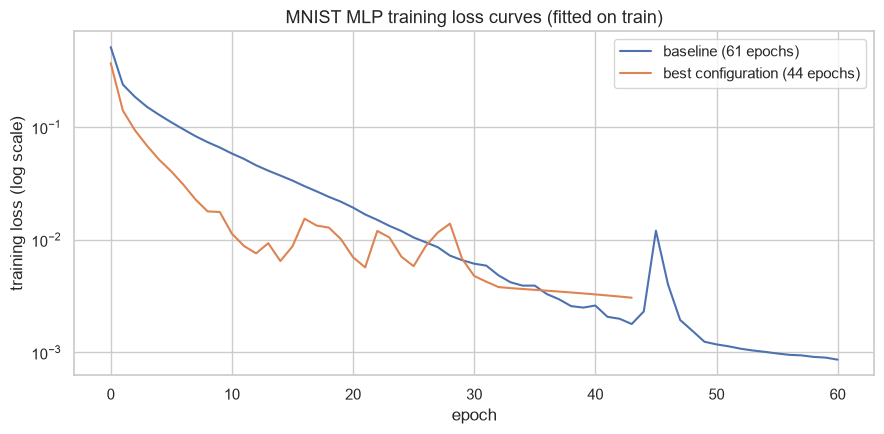

In [82]:
mnist_mlp_best_validation = load_or_train("mnist_mlp_best_validation", make_mnist_mlp, mnist_mlp_best_params,
                                          Xm_train, ym_train, mnist_idx_train)

plt.figure(figsize=(9, 4.5))
for label, bundle in [("baseline", mnist_mlp_baseline), ("best configuration", mnist_mlp_best_validation)]:
    net = bundle["pipeline"].named_steps["classifier"]
    plt.plot(net.loss_curve_, label=f"{label} ({net.n_iter_} epochs)")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("training loss (log scale)")
plt.title("MNIST MLP training loss curves (fitted on train)", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

- All configurations converged (no ConvergenceWarning).
- Best: `(256, 128)`, `alpha=1e-3` — validation Macro F1 **0.9803** (baseline 0.9733).
- Loss curves: smooth convergence; the selected network ends at a higher training loss, consistent with its stronger
  L2 penalty (the architectures also differ).

[checkpoint] loaded checkpoints\mnist_mlp_final.joblib
  fitted on 56000 samples, training time 83.032s
Final MLP: 59 epochs, converged: True
=== MLP final — evaluation on the MNIST TEST set ===
Hyperparameters : {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.001, 'max_iter': 200}
Training time   : 83.03 s | Prediction time (14000 images): 0.07 s
Test errors     : 220 / 14000

Accuracy              0.9843
Precision Macro       0.9841
Recall Macro          0.9841
F1 Macro              0.9841
Precision Weighted    0.9843
Recall Weighted       0.9843
F1 Weighted           0.9843

--- Classification report (per class) ---
              precision    recall  f1-score   support

           0     0.9871    0.9978    0.9924      1381
           1     0.9917    0.9917    0.9917      1575
           2     0.9856    0.9807    0.9831      1398
           3     0.9894    0.9825    0.9859      1428
           4     0.9809    0.9788    0.9798      1365

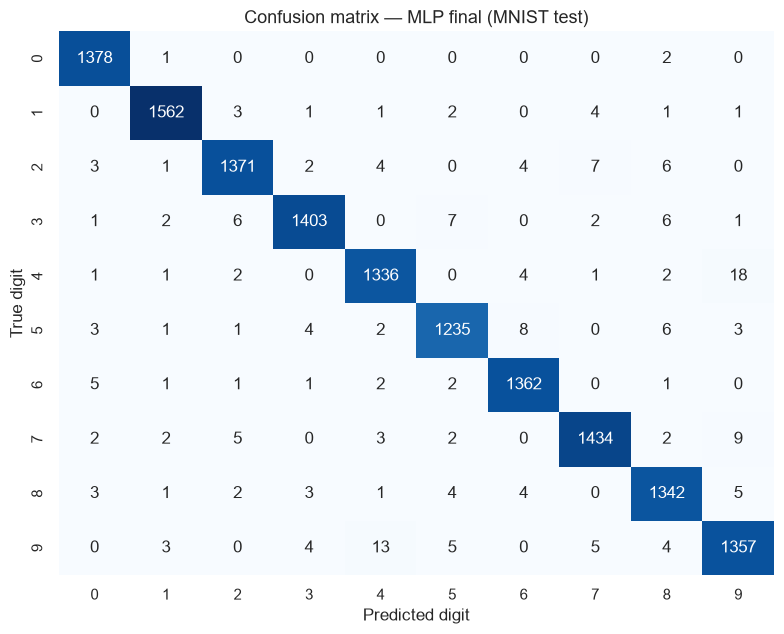

Most frequent confusions (true→predicted): 4→9 (18), 9→4 (13), 7→9 (9), 5→6 (8), 2→7 (7), 3→5 (7)


In [83]:
Xm_train_val = np.concatenate([Xm_train, Xm_val])   # same row order as mnist_idx_train_val
mnist_mlp_final = load_or_train("mnist_mlp_final", make_mnist_mlp, mnist_mlp_best_params,
                                Xm_train_val, ym_train_val, mnist_idx_train_val)
net = mnist_mlp_final["pipeline"].named_steps["classifier"]
print(f"Final MLP: {net.n_iter_} epochs, converged: {net.n_iter_ < net.max_iter}")

y_pred, metrics, pred_time = mnist_evaluate_on_test("mnist_mlp_final",
                                                    lambda: mnist_mlp_final["pipeline"].predict(Xm_test))
MNIST_FINAL["MLP"] = {"y_pred": y_pred, "metrics": metrics, "pred_time": pred_time,
                      "fit_time": mnist_mlp_final["fit_time_s"],
                      "params": {k: v for k, v in mnist_mlp_best_params.items() if k != "input_version"},
                      "n_parameters": sum(w.size for w in net.coefs_) + sum(b.size for b in net.intercepts_),
                      "notes": f"flattened 784 inputs; {net.n_iter_} epochs on train + validation"}
mnist_report("MLP final", MNIST_FINAL["MLP"])

- Test: Accuracy **0.9843**, Macro F1 **0.9841**, 220 errors; main confusions 4 ↔ 9.
- Fastest prediction (0.06 s); 83 s training on CPU.

*Memory:* MLPs and all float32 feature matrices released before the CNN.

In [84]:
keep_bundle_info(mnist_mlp_baseline, mnist_mlp_best_validation, mnist_mlp_final)
del mnist_mlp_baseline, mnist_mlp_best_validation, mnist_mlp_final, net
del Xm_train, Xm_val, Xm_test, Xm_train_val, y_pred
gc.collect()
report_memory("before the CNN (classical models and float feature matrices released)")

[memory] before the CNN (classical models and float feature matrices released): current 702 MB | peak so far 1,278 MB


### 13.7 Convolutional Neural Network (CNN)

`Input 1×28×28 → Conv(32, 3×3) + ReLU → MaxPool → Conv(64, 3×3) + ReLU → MaxPool → Flatten → Dense(128) + ReLU → Output(10)`

- Loss: cross-entropy; optimizer: Adam (lr = 1e-3); batch size 128.
- Early stopping on validation Macro F1 (patience 3, max 12 epochs); no architecture search.

#### Reproducibility and device

In [85]:
import os

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")   # required by deterministic cuBLAS (set before CUDA is used)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda"
                              else f" ({torch.get_num_threads()} CPU threads)"))

Device: cuda (NVIDIA GeForce RTX 3060 Laptop GPU)


- GPU if available, otherwise CPU; fixed seeds and deterministic algorithms.

#### Architecture

In [86]:
class SimpleCNN(nn.Module):
    def __init__(self, conv1_channels=32, conv2_channels=64, hidden_units=128, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, conv1_channels, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(conv1_channels, conv2_channels, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv2_channels * 7 * 7, hidden_units), nn.ReLU(),
            nn.Linear(hidden_units, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


CNN_CONFIG = {
    "architecture": {"conv1_channels": 32, "conv2_channels": 64, "hidden_units": 128},
    "batch_size": 128,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "loss": "CrossEntropyLoss",
    "max_epochs": 12,
    "patience": 3,          # early stopping: epochs without improvement of validation F1 macro
    "seed": RANDOM_STATE,
    "input_version": MNIST_INPUT,
    "data_loading": "torchvision MNIST uint8 -> DataLoader -> float / 255 per batch",
}

set_seed(CNN_CONFIG["seed"])
cnn_preview = SimpleCNN(**CNN_CONFIG["architecture"])
print(cnn_preview)

x = torch.zeros(1, 1, 28, 28)
print("\nShape of the data through the network:")
print(f"  {'input':<10} {tuple(x.shape)}")
for layer in [*cnn_preview.features, *cnn_preview.classifier]:
    x = layer(x)
    print(f"  {layer.__class__.__name__:<10} {tuple(x.shape)}")

cnn_param_table = pd.DataFrame([{"parameter": name, "shape": tuple(p.shape), "count": p.numel()}
                                for name, p in cnn_preview.named_parameters() if p.requires_grad])
cnn_n_params = int(cnn_param_table["count"].sum())
print(f"\nTrainable parameters: {cnn_n_params:,}")
cnn_param_table

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Shape of the data through the network:
  input      (1, 1, 28, 28)
  Conv2d     (1, 32, 28, 28)
  ReLU       (1, 32, 28, 28)
  MaxPool2d  (1, 32, 14, 14)
  Conv2d     (1, 64, 14, 14)
  ReLU       (1, 64, 14, 14)
  MaxPool2d  (1, 64, 7, 7)
  Flatten    (1, 3136)
  Linear     (1, 128)
  ReLU       (1, 128)
  Linear     (1, 10)

Trainable parameters: 421,642


,parameter,shape,count
0,features.0.weight,"(32, 1, 3, 3)",288
1,features.0.bias,"(32,)",32
2,features.3.weight,"(64, 32, 3, 3)",18432
3,features.3.bias,"(64,)",64
4,classifier.1.weight,"(128, 3136)",401408
5,classifier.1.bias,"(128,)",128
6,classifier.3.weight,"(10, 128)",1280
7,classifier.3.bias,"(10,)",10


#### Training with early stopping

- Trained on train only; validation loss, accuracy and Macro F1 recorded every epoch.
- Best model saved to `checkpoints/mnist_cnn_best.pt` on every improvement.

#### Data loading

- uint8 images from torchvision through a `DataLoader`; each batch is converted to float32 / 255.

In [87]:
class PooledMNIST(Dataset):
    # Official train part followed by the official test part (the same order as mnist_images / mnist_labels)
    def __init__(self, train_part, test_part):
        self.train_part, self.test_part = train_part, test_part
        self.offset = len(train_part)

    def __len__(self):
        return self.offset + len(self.test_part)

    def __getitem__(self, i):
        part, j = (self.train_part, i) if i < self.offset else (self.test_part, i - self.offset)
        return part.data[j], int(part.targets[j])   # uint8 image (28, 28), label


def to_model_input(images_uint8):
    # Per-batch transform: uint8 (batch, 28, 28) -> float32 in [0, 1] with shape (batch, 1, 28, 28)
    return images_uint8.unsqueeze(1).float().div(255.0)


pooled_mnist = PooledMNIST(mnist_train_part, mnist_test_part)


def mnist_loader(ids, shuffle, generator=None, batch_size=1000):
    return DataLoader(Subset(pooled_mnist, ids.tolist()), batch_size=batch_size, shuffle=shuffle,
                      generator=generator, num_workers=0)


# Same observations and bit-for-bit the same values as the feature matrices used by KNN / SVM / MLP
# (checked on 64 validation rows, so the test set is not touched before the final evaluation)
check_images, check_labels = next(iter(mnist_loader(mnist_idx_val[:64], shuffle=False)))
assert np.array_equal(to_model_input(check_images).reshape(64, -1).numpy(), mnist_features(mnist_idx_val[:64]))
assert np.array_equal(check_labels.numpy(), ym_val[:64])
del check_images, check_labels
print("DataLoader batches match the feature matrices used by the other models (values and labels).")

DataLoader batches match the feature matrices used by the other models (values and labels).


#### Training helpers

In [88]:
cnn_loss_fn = nn.CrossEntropyLoss()


def cnn_logits(model, loader):
    model.eval()
    outputs = []
    with torch.no_grad():
        for images, _ in loader:
            outputs.append(model(to_model_input(images).to(device)).cpu())
    return torch.cat(outputs)


def cnn_train_epoch(model, optimizer, loader):
    model.train()
    total_loss, correct, seen = 0.0, 0, 0
    for images, labels in loader:
        xb, yb = to_model_input(images).to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = cnn_loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        seen += len(yb)
    return total_loss / seen, correct / seen


cnn_val_loader = mnist_loader(mnist_idx_val, shuffle=False)


def cnn_validate(model):
    logits = cnn_logits(model, cnn_val_loader)
    y_pred = logits.argmax(1).numpy()
    return (float(cnn_loss_fn(logits, torch.from_numpy(ym_val)).item()), float(accuracy_score(ym_val, y_pred)),
            float(f1_score(ym_val, y_pred, average="macro")))

In [89]:
def new_cnn(train_ids):
    # Fresh model, optimizer and seeded shuffling of the given training rows
    set_seed(CNN_CONFIG["seed"])
    model = SimpleCNN(**CNN_CONFIG["architecture"]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=CNN_CONFIG["learning_rate"])
    generator = torch.Generator().manual_seed(CNN_CONFIG["seed"])
    loader = mnist_loader(train_ids, shuffle=True, generator=generator, batch_size=CNN_CONFIG["batch_size"])
    return model, optimizer, loader


def load_cnn_checkpoint(path, expected_fp):
    if FORCE_RETRAIN or not path.exists():
        return None
    ckpt = torch.load(path, map_location="cpu", weights_only=True)
    if ckpt.get("completed") and ckpt.get("config") == CNN_CONFIG and ckpt.get("data_fingerprint") == expected_fp:
        return ckpt
    print(f"[checkpoint] {path} does not match the current configuration/data -> retraining")
    return None

In [90]:
CNN_BEST_PATH = CHECKPOINT_DIR / "mnist_cnn_best.pt"
cnn_dev_fp = f"{fingerprint(mnist_idx_train)}-{fingerprint(mnist_idx_val)}"

cnn_best_ckpt = load_cnn_checkpoint(CNN_BEST_PATH, cnn_dev_fp)
if cnn_best_ckpt is not None:
    print(f"[checkpoint] loaded {CNN_BEST_PATH} (best epoch {cnn_best_ckpt['epoch']}, "
          f"validation F1 macro {cnn_best_ckpt['val_f1_macro']:.4f}, training time {cnn_best_ckpt['train_time_s']:.0f}s)")
else:
    model, optimizer, train_loader = new_cnn(mnist_idx_train)
    history, best_f1, epochs_without_improvement = [], -1.0, 0
    start = time.perf_counter()
    for epoch in range(1, CNN_CONFIG["max_epochs"] + 1):
        epoch_start = time.perf_counter()
        train_loss, train_acc = cnn_train_epoch(model, optimizer, train_loader)
        val_loss, val_acc, val_f1 = cnn_validate(model)
        history.append({"epoch": epoch, "train_loss": train_loss, "train_accuracy": train_acc, "val_loss": val_loss,
                        "val_accuracy": val_acc, "val_f1_macro": val_f1,
                        "epoch_time_s": time.perf_counter() - epoch_start})
        improved = val_f1 > best_f1
        print(f"epoch {epoch:2d} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} "
              f"acc {val_acc:.4f} F1 {val_f1:.4f} | {history[-1]['epoch_time_s']:.1f}s"
              + ("  <- new best, checkpoint saved" if improved else ""))
        if improved:
            best_f1, epochs_without_improvement = val_f1, 0
            torch.save({"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
                        "epoch": epoch, "val_f1_macro": val_f1, "val_accuracy": val_acc, "config": CNN_CONFIG,
                        "data_fingerprint": cnn_dev_fp, "history": history, "completed": False,
                        "torch_version": str(torch.__version__)}, CNN_BEST_PATH)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= CNN_CONFIG["patience"]:
                print(f"Early stopping: no improvement of validation F1 for {CNN_CONFIG['patience']} epochs.")
                break
    cnn_best_ckpt = torch.load(CNN_BEST_PATH, map_location="cpu", weights_only=True)
    cnn_best_ckpt.update({"history": history, "completed": True, "train_time_s": time.perf_counter() - start})
    torch.save(cnn_best_ckpt, CNN_BEST_PATH)
    print(f"[checkpoint] training finished; best epoch {cnn_best_ckpt['epoch']} saved in {CNN_BEST_PATH}")
    del model, optimizer, train_loader   # the best weights live in the checkpoint
    gc.collect()

cnn_best_epoch = cnn_best_ckpt["epoch"]
cnn_history = pd.DataFrame(cnn_best_ckpt["history"]).set_index("epoch")
cnn_best_model = SimpleCNN(**CNN_CONFIG["architecture"]).to(device)
cnn_best_model.load_state_dict(cnn_best_ckpt["model_state_dict"])
assert abs(cnn_validate(cnn_best_model)[2] - cnn_best_ckpt["val_f1_macro"]) < 1e-9   # reloaded model = saved scores
report_memory("after the CNN development training")
cnn_history.round(4)

[checkpoint] loaded checkpoints\mnist_cnn_best.pt (best epoch 8, validation F1 macro 0.9885, training time 19s)
[memory] after the CNN development training: current 1,034 MB | peak so far 1,278 MB


,train_loss,train_accuracy,val_loss,val_accuracy,val_f1_macro,epoch_time_s
epoch,,,,,,
1,0.3252,0.9042,0.1130,0.9678,0.9676,2.0114
2,0.0710,0.9785,0.0603,0.9812,0.9812,1.6327
3,0.0469,0.9858,0.0595,0.9819,0.9817,1.6138
4,0.0367,0.9890,0.0494,0.9858,0.9857,1.6496
5,0.0290,0.9914,0.0464,0.9853,0.9852,1.6483
6,0.0236,0.9921,0.0471,0.9859,0.9859,1.6668
7,0.0173,0.9948,0.0473,0.9859,0.9859,1.6659
8,0.0135,0.9955,0.0417,0.9885,0.9885,1.9947
9,0.0111,0.9965,0.0432,0.9875,0.9875,1.8793


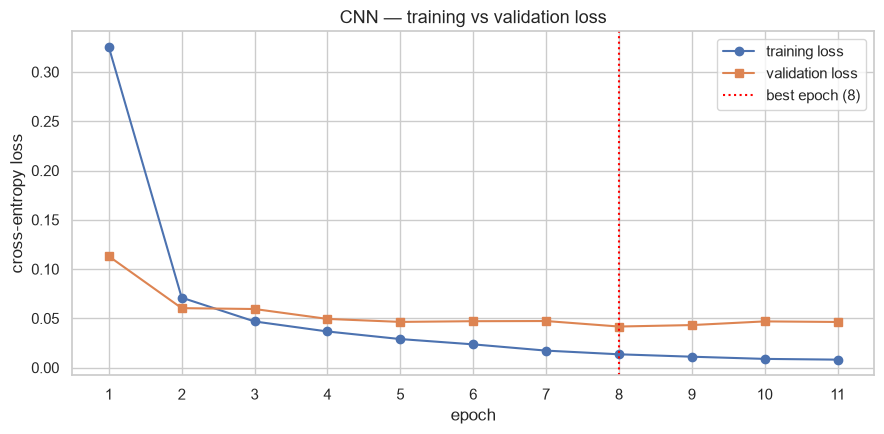

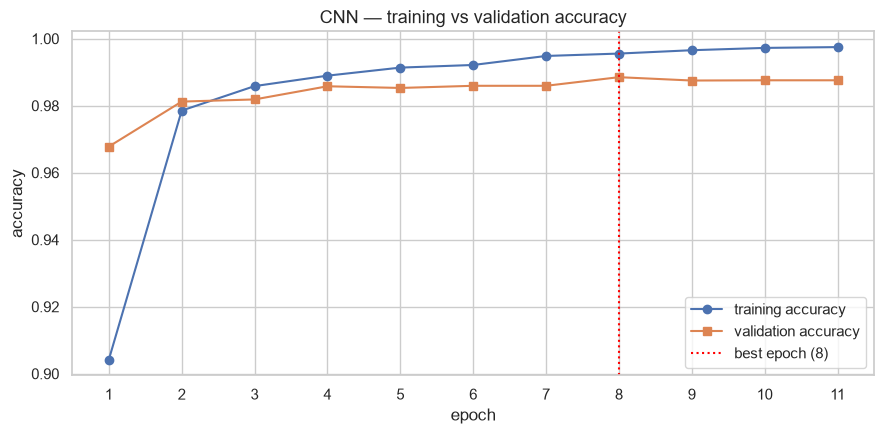

In [91]:
plt.figure(figsize=(9, 4.5))
plt.plot(cnn_history.index, cnn_history["train_loss"], marker="o", label="training loss")
plt.plot(cnn_history.index, cnn_history["val_loss"], marker="s", label="validation loss")
plt.axvline(cnn_best_epoch, color="red", linestyle=":", label=f"best epoch ({cnn_best_epoch})")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("CNN — training vs validation loss", fontsize=13)
plt.xticks(cnn_history.index)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.5))
plt.plot(cnn_history.index, cnn_history["train_accuracy"], marker="o", label="training accuracy")
plt.plot(cnn_history.index, cnn_history["val_accuracy"], marker="s", label="validation accuracy")
plt.axvline(cnn_best_epoch, color="red", linestyle=":", label=f"best epoch ({cnn_best_epoch})")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("CNN — training vs validation accuracy", fontsize=13)
plt.xticks(cnn_history.index)
plt.legend()
plt.tight_layout()
plt.show()

- Best epoch: **8** (validation Macro F1 **0.9885**, lowest validation loss); early stopping after 11 epochs.
- After epoch 8 the training loss keeps falling while the validation loss stops improving, consistent with the onset
  of over-fitting.

#### Final CNN (train + validation)

- Retrained from scratch for the best number of epochs (8), saved to `checkpoints/mnist_cnn_final.pt`, then evaluated on test.

[checkpoint] loaded checkpoints\mnist_cnn_final.pt (8 epochs, training time 16s)
=== CNN final — evaluation on the MNIST TEST set ===
Hyperparameters : {'conv1_channels': 32, 'conv2_channels': 64, 'hidden_units': 128, 'epochs': 8, 'batch_size': 128, 'lr': 0.001}
Training time   : 16.07 s | Prediction time (14000 images): 0.19 s
Test errors     : 161 / 14000

Accuracy              0.9885
Precision Macro       0.9885
Recall Macro          0.9884
F1 Macro              0.9884
Precision Weighted    0.9886
Recall Weighted       0.9885
F1 Weighted           0.9885

--- Classification report (per class) ---
              precision    recall  f1-score   support

           0     0.9864    0.9971    0.9917      1381
           1     0.9955    0.9937    0.9946      1575
           2     0.9914    0.9886    0.9900      1398
           3     0.9916    0.9923    0.9919      1428
           4     0.9918    0.9766    0.9841      1365
           5     0.9929    0.9905    0.9917      1263
           6  

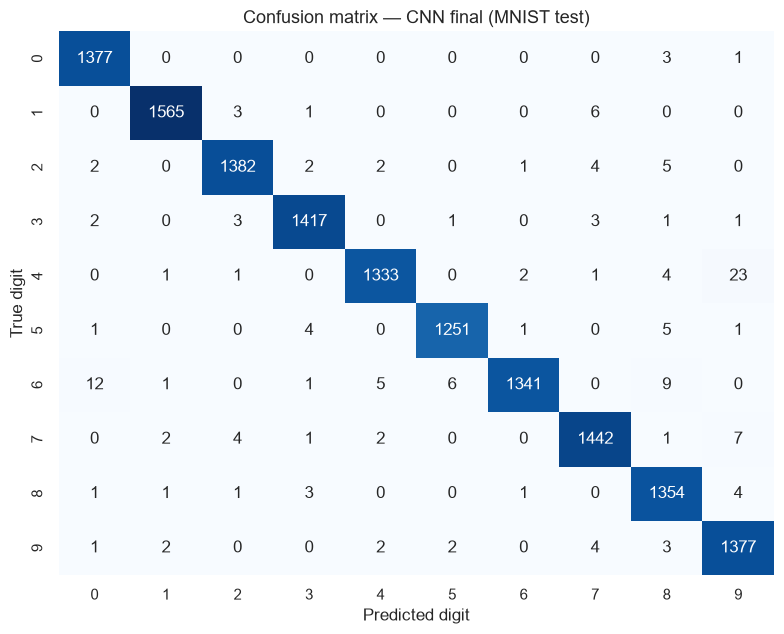

Most frequent confusions (true→predicted): 4→9 (23), 6→0 (12), 6→8 (9), 7→9 (7), 1→7 (6), 6→5 (6)


In [92]:
CNN_FINAL_PATH = CHECKPOINT_DIR / "mnist_cnn_final.pt"
cnn_final_fp = fingerprint(mnist_idx_train_val)

cnn_final_ckpt = load_cnn_checkpoint(CNN_FINAL_PATH, cnn_final_fp)
if cnn_final_ckpt is not None and cnn_final_ckpt["epochs"] == cnn_best_epoch:
    print(f"[checkpoint] loaded {CNN_FINAL_PATH} ({cnn_final_ckpt['epochs']} epochs, "
          f"training time {cnn_final_ckpt['train_time_s']:.0f}s)")
else:
    model, optimizer, train_val_loader = new_cnn(mnist_idx_train_val)
    final_history = []
    start = time.perf_counter()
    for epoch in range(1, cnn_best_epoch + 1):
        train_loss, train_acc = cnn_train_epoch(model, optimizer, train_val_loader)
        final_history.append({"epoch": epoch, "train_loss": train_loss, "train_accuracy": train_acc})
        print(f"epoch {epoch:2d} | train loss {train_loss:.4f} acc {train_acc:.4f}")
    cnn_final_ckpt = {"model_state_dict": model.state_dict(), "epochs": cnn_best_epoch, "config": CNN_CONFIG,
                      "data_fingerprint": cnn_final_fp, "history": final_history, "completed": True,
                      "train_time_s": time.perf_counter() - start, "torch_version": str(torch.__version__)}
    torch.save(cnn_final_ckpt, CNN_FINAL_PATH)
    print(f"[checkpoint] trained and saved {CNN_FINAL_PATH} in {cnn_final_ckpt['train_time_s']:.0f}s")
    del model, optimizer, train_val_loader
    gc.collect()

cnn_final_model = SimpleCNN(**CNN_CONFIG["architecture"]).to(device)
cnn_final_model.load_state_dict(cnn_final_ckpt["model_state_dict"])

y_pred, metrics, pred_time = mnist_evaluate_on_test(
    "mnist_cnn_final", lambda: cnn_logits(cnn_final_model, mnist_loader(mnist_idx_test, shuffle=False)).argmax(1).numpy())
MNIST_FINAL["CNN"] = {"y_pred": y_pred, "metrics": metrics, "pred_time": pred_time,
                      "fit_time": cnn_final_ckpt["train_time_s"],
                      "params": {**CNN_CONFIG["architecture"], "epochs": cnn_best_epoch,
                                 "batch_size": CNN_CONFIG["batch_size"], "lr": CNN_CONFIG["learning_rate"]},
                      "notes": f"1×28×28 input; {cnn_n_params:,} parameters; {cnn_best_epoch} epochs on train + "
                               f"validation ({device.type})"}
mnist_report("CNN final", MNIST_FINAL["CNN"])

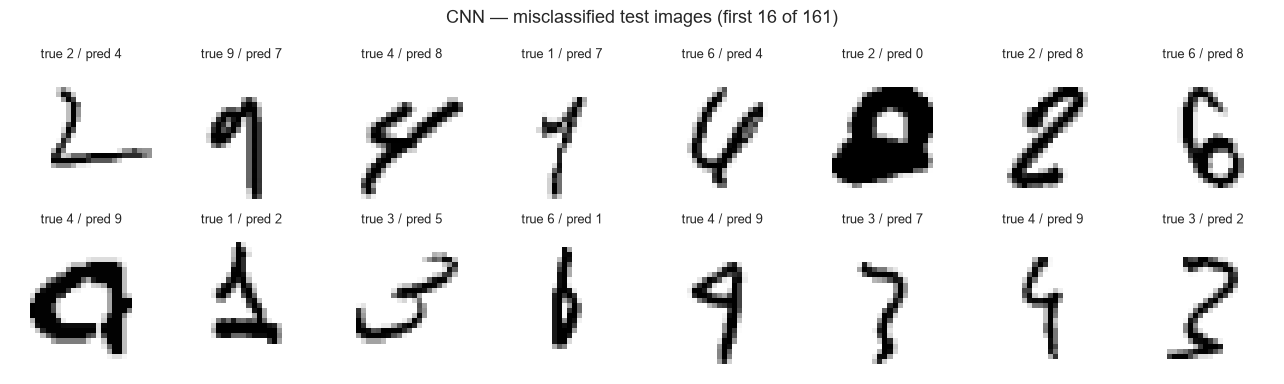

[memory] GPU peak allocated by PyTorch: 230 MB
[memory] after the CNN: current 1,038 MB | peak so far 1,278 MB


In [93]:
cnn_wrong_idx = np.flatnonzero(MNIST_FINAL["CNN"]["y_pred"] != ym_test)
fig, axes = plt.subplots(2, 8, figsize=(13, 4))
for ax, i in zip(axes.ravel(), cnn_wrong_idx[:16]):
    ax.imshow(mnist_images[mnist_idx_test[i]], cmap="gray_r")
    ax.set_title(f"true {ym_test[i]} / pred {MNIST_FINAL['CNN']['y_pred'][i]}", fontsize=9)
for ax in axes.ravel():
    ax.axis("off")
plt.suptitle(f"CNN — misclassified test images (first {min(16, len(cnn_wrong_idx))} of {len(cnn_wrong_idx)})",
             fontsize=13)
plt.tight_layout()
plt.show()

# The CNN results are stored in MNIST_FINAL; the development model and the temporary prediction array are released
del cnn_best_model, y_pred
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"[memory] GPU peak allocated by PyTorch: {torch.cuda.max_memory_allocated() / 2**20:,.0f} MB")
report_memory("after the CNN")

- Test: Accuracy **0.9885**, Macro F1 **0.9884**, 161 errors; main confusion 4 → 9 (23).
- 16 s training on GPU.

### 13.8 MNIST Results Comparison

- Test-set results of the final models (trained on 56 000 images, evaluated on 14 000).
- CNN timings are on GPU; the other models on CPU.

In [94]:
mnist_comparison = pd.DataFrame([
    {"Model": model, **r["metrics"], "Test errors": int((r["y_pred"] != ym_test).sum()),
     "Training Time (s)": r["fit_time"], "Prediction Time (s)": r["pred_time"], "Notes": r["notes"]}
    for model, r in MNIST_FINAL.items()
]).set_index("Model")

mnist_comparison.style.format({**{c: "{:.4f}" for c in metric_columns},
                               "Training Time (s)": "{:.2f}", "Prediction Time (s)": "{:.2f}"}) \
    .highlight_max(subset=metric_columns, color="lightgreen")

,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted,Test errors,Training Time (s),Prediction Time (s),Notes
Model,,,,,,,,,,,
KNN,0.9732,0.9736,0.9728,0.9731,0.9734,0.9732,0.9732,375,0.03,12.17,lazy learner: fit only stores 56 000 images; cost is at prediction time
SVM,0.9834,0.9834,0.9833,0.9833,0.9834,0.9834,0.9834,232,152.19,76.92,C/gamma chosen on a 10000-image training subset; final fit on 56 000
MLP,0.9843,0.9841,0.9841,0.9841,0.9843,0.9843,0.9843,220,83.03,0.07,flattened 784 inputs; 59 epochs on train + validation
CNN,0.9885,0.9885,0.9884,0.9884,0.9886,0.9885,0.9885,161,16.07,0.19,"1×28×28 input; 421,642 parameters; 8 epochs on train + validation (cuda)"


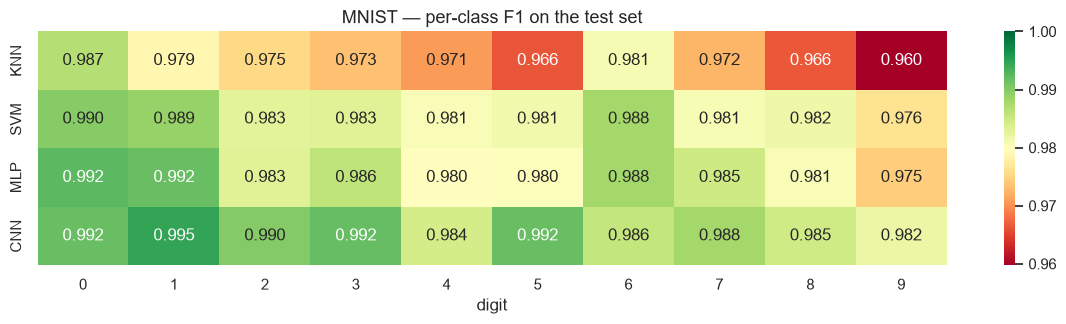

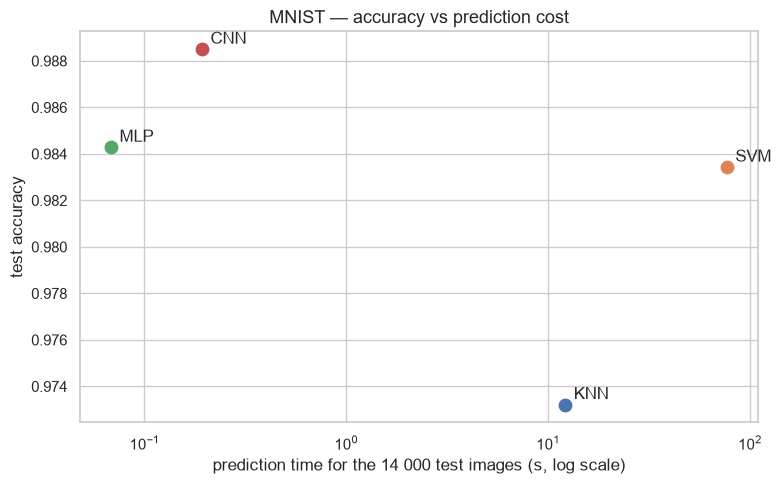

In [95]:
mnist_per_class_f1 = pd.DataFrame({
    model: f1_score(ym_test, r["y_pred"], average=None, labels=range(10)) for model, r in MNIST_FINAL.items()
}, index=pd.Index(range(10), name="digit")).T

plt.figure(figsize=(12, 3.4))
sns.heatmap(mnist_per_class_f1, annot=True, fmt=".3f", cmap="RdYlGn", vmin=mnist_per_class_f1.values.min(), vmax=1.0)
plt.title("MNIST — per-class F1 on the test set", fontsize=13)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for model, row in mnist_comparison.iterrows():
    plt.scatter(row["Prediction Time (s)"], row["Accuracy"], s=80)
    plt.annotate(model, (row["Prediction Time (s)"], row["Accuracy"]), textcoords="offset points", xytext=(6, 4))
plt.xscale("log")
plt.xlabel("prediction time for the 14 000 test images (s, log scale)")
plt.ylabel("test accuracy")
plt.title("MNIST — accuracy vs prediction cost", fontsize=13)
plt.tight_layout()
plt.show()

- CNN obtained the highest MNIST test performance (161 errors), then MLP (220), SVM (232) and KNN (375).
- MLP and SVM obtained very similar results on this test split.
- 4 → 9 is the most frequent confusion for all four models.
- Cost: SVM is the most expensive to train and predict; KNN is costly at prediction; MLP has the fastest prediction.

### 13.9 CNN vs MLP

- MLP: flattened 784-dimensional input.
- CNN: preserves the 2D spatial structure (shared local filters).

In [96]:
mlp_n_params = MNIST_FINAL["MLP"]["n_parameters"]
mlp_wrong = MNIST_FINAL["MLP"]["y_pred"] != ym_test
cnn_wrong = MNIST_FINAL["CNN"]["y_pred"] != ym_test

cnn_vs_mlp = pd.DataFrame({
    "MLP": {"input": "784 flattened pixels", "trainable parameters": mlp_n_params,
            "test accuracy": MNIST_FINAL["MLP"]["metrics"]["Accuracy"],
            "test F1 macro": MNIST_FINAL["MLP"]["metrics"]["F1 Macro"], "test errors": int(mlp_wrong.sum()),
            "training time (s)": MNIST_FINAL["MLP"]["fit_time"], "prediction time (s)": MNIST_FINAL["MLP"]["pred_time"]},
    "CNN": {"input": "1×28×28 image", "trainable parameters": cnn_n_params,
            "test accuracy": MNIST_FINAL["CNN"]["metrics"]["Accuracy"],
            "test F1 macro": MNIST_FINAL["CNN"]["metrics"]["F1 Macro"], "test errors": int(cnn_wrong.sum()),
            "training time (s)": MNIST_FINAL["CNN"]["fit_time"], "prediction time (s)": MNIST_FINAL["CNN"]["pred_time"]},
})
print(f"Test errors made by both: {int((mlp_wrong & cnn_wrong).sum())} | only MLP: {int((mlp_wrong & ~cnn_wrong).sum())}"
      f" | only CNN: {int((~mlp_wrong & cnn_wrong).sum())}")
print(f"Relative error reduction of the CNN w.r.t. the MLP: {1 - cnn_wrong.sum() / mlp_wrong.sum():.1%}")
cnn_vs_mlp

Test errors made by both: 89 | only MLP: 131 | only CNN: 72
Relative error reduction of the CNN w.r.t. the MLP: 26.8%


,MLP,CNN
input,784 flattened pixels,1×28×28 image
trainable parameters,235146,421642
test accuracy,0.9843,0.9885
test F1 macro,0.9841,0.9884
test errors,220,161
training time (s),83.032,16.0716
prediction time (s),0.0684,0.1931


- CNN obtained the highest MNIST test performance (161 vs 220 errors).
- The observed difference cannot be attributed exclusively to convolution: architecture, parameter count and
  training procedure also differ.

### 13.10 Digits vs MNIST

- Accuracies are not directly comparable (different images, resolutions and test sets).

In [97]:
digits_vs_mnist = {
    "images": (len(digits.target), len(mnist_labels)),
    "image size": (size_label(digits.images.shape[1:]), size_label(mnist_images.shape[1:])),
    "features": (digits.data.shape[1], MNIST_N_FEATURES),
    "training images of the final models": (len(y_train_val), len(mnist_idx_train_val)),
    "test images": (len(y_test), len(mnist_idx_test)),
    "KNN prediction time per query (ms)": (round(digits_ms_per_query, 4), round(mnist_ms_per_query, 4)),
}
for model in ["KNN", "SVM", "MLP", "CNN"]:
    d, m = FINAL_RESULTS.get(model), MNIST_FINAL.get(model)
    digits_vs_mnist[f"{model} — test accuracy"] = (
        round(d["metrics"]["Accuracy"], 4) if d else "not run", round(m["metrics"]["Accuracy"], 4) if m else "not run")
    digits_vs_mnist[f"{model} — final training time (s)"] = (
        round(d["bundle"]["fit_time_s"], 3) if d else "not run", round(m["fit_time"], 2) if m else "not run")
pd.DataFrame(digits_vs_mnist, index=["Digits", "MNIST"]).T

,Digits,MNIST
images,1797,70000
image size,8×8,28×28
features,64,784
training images of the final models,1437,56000
test images,360,14000
KNN prediction time per query (ms),0.0409,0.5169
KNN — test accuracy,0.9861,0.9732
KNN — final training time (s),0.001,0.03
SVM — test accuracy,0.9833,0.9834
SVM — final training time (s),0.031,152.19


- MNIST: 39× more samples and 12× more features.
- Training cost grew sharply (SVM: 0.03 s → 152 s); KNN per-query cost grew 21×.
- KNN went from the best result on Digits to the lowest on MNIST.
- The CNN (MNIST only) obtained the best MNIST result.

### 13.11 MNIST Methodology Verification

In [98]:
m_checks = {}
m_checks["train/validation/test disjoint and covering all 70 000 images"] = bool(
    len(np.intersect1d(mnist_idx_train, mnist_idx_val)) == 0 and len(np.intersect1d(mnist_idx_train, mnist_idx_test)) == 0
    and len(np.intersect1d(mnist_idx_val, mnist_idx_test)) == 0
    and len(np.union1d(mnist_idx_train_val, mnist_idx_test)) == len(mnist_labels))
m_checks["split ≈ 60/20/20 (±1 pp)"] = bool(np.allclose(
    np.array([len(mnist_idx_train), len(mnist_idx_val), len(mnist_idx_test)]) / len(mnist_labels), [0.6, 0.2, 0.2],
    atol=0.01))
m_checks["stratified: class proportions within 0.5 pp"] = bool(mnist_max_deviation < 0.5)
saved_split = joblib.load(MNIST_SPLIT_PATH)
m_checks["saved split indices identical to the ones used"] = all(
    np.array_equal(saved_split[k], v) for k, v in mnist_split.items())

val_fp = fingerprint(mnist_idx_val)
tuning_fps = {"mnist_svm_tuning": f"{fingerprint(svm_tuning_ids)}-{val_fp}",
              "mnist_mlp_tuning_architecture": f"{fingerprint(mnist_idx_train)}-{val_fp}",
              "mnist_mlp_tuning_alpha": f"{fingerprint(mnist_idx_train)}-{val_fp}"}
if run_full_knn:
    tuning_fps["mnist_knn_tuning"] = f"{fingerprint(mnist_idx_train)}-{val_fp}"
m_checks["tuning: fitted on training rows, scored on validation (no test)"] = bool(
    all(joblib.load(CHECKPOINT_DIR / f"{name}.joblib")["data_fingerprint"] == fp for name, fp in tuning_fps.items())
    and np.isin(svm_tuning_ids, mnist_idx_train).all() and np.isin(knn_bench_queries, mnist_idx_val).all())
info = {name: meta["data_fingerprint"] for name, meta in MNIST_BUNDLE_INFO.items()}
m_checks["same observations: development models on train, final models on train + validation"] = bool(
    info["mnist_svm_baseline"] == info["mnist_svm_best_validation"] == fingerprint(svm_tuning_ids)
    and info["mnist_mlp_baseline"] == info["mnist_mlp_best_validation"] == fingerprint(mnist_idx_train)
    and info["mnist_svm_final"] == info["mnist_mlp_final"] == cnn_final_fp == fingerprint(mnist_idx_train_val)
    and MNIST_BUNDLE_INFO["mnist_svm_final"]["n_samples"] == MNIST_BUNDLE_INFO["mnist_mlp_final"]["n_samples"]
    == len(mnist_idx_train_val))
m_checks["CNN never trained on test (best: train, final: train + validation)"] = bool(
    cnn_best_ckpt["data_fingerprint"] == cnn_dev_fp and cnn_final_ckpt["data_fingerprint"] == cnn_final_fp)
expected_log = (["mnist_knn_final"] if run_full_knn else []) + ["mnist_svm_final", "mnist_mlp_final", "mnist_cnn_final"]
m_checks["test set used only by final models, once each"] = MNIST_TEST_LOG == expected_log
m_checks["prediction arrays have the test-set length"] = all(
    r["y_pred"].shape == ym_test.shape for r in MNIST_FINAL.values())
m_checks["all 10 classes present in test labels and in every model's predictions"] = (
    set(np.unique(ym_test)) == set(range(10))
    and all(set(np.unique(r["y_pred"])) == set(range(10)) for r in MNIST_FINAL.values()))
mnist_expected_files = ["mnist_split_indices.joblib", "mnist_knn_scalability_benchmark.joblib",
                        "mnist_svm_cost_probe.joblib", "mnist_svm_baseline.joblib", "mnist_svm_best_validation.joblib",
                        "mnist_svm_final.joblib", "mnist_mlp_baseline.joblib", "mnist_mlp_best_validation.joblib",
                        "mnist_mlp_final.joblib", "mnist_cnn_best.pt", "mnist_cnn_final.pt"]
m_checks["checkpoints exist"] = all((CHECKPOINT_DIR / f).exists() for f in mnist_expected_files)

mnist_verification = pd.Series(m_checks, name="passed").to_frame()
display(mnist_verification)
assert mnist_verification["passed"].all(), "At least one MNIST methodological check failed"
print("All MNIST checks passed. Test-set access log:", MNIST_TEST_LOG)
report_memory("end of the notebook")

pd.DataFrame([{"file": p.name, "size (MB)": round(p.stat().st_size / 2**20, 2)}
              for p in sorted(CHECKPOINT_DIR.glob("mnist_*"))])

,passed
train/validation/test disjoint and covering all 70 000 images,True
split ≈ 60/20/20 (±1 pp),True
stratified: class proportions within 0.5 pp,True
saved split indices identical to the ones used,True
"tuning: fitted on training rows, scored on validation (no test)",True
"same observations: development models on train, final models on train + validation",True
"CNN never trained on test (best: train, final: train + validation)",True
"test set used only by final models, once each",True
prediction arrays have the test-set length,True
all 10 classes present in test labels and in every model's predictions,True


All MNIST checks passed. Test-set access log: ['mnist_knn_final', 'mnist_svm_final', 'mnist_mlp_final', 'mnist_cnn_final']
[memory] end of the notebook: current 1,043 MB | peak so far 1,278 MB


,file,size (MB)
0,mnist_cnn_best.pt,4.84
1,mnist_cnn_final.pt,1.61
2,mnist_knn_scalability_benchmark.joblib,0.00
3,mnist_knn_tuning.joblib,0.00
4,mnist_mlp_baseline.joblib,1.22
5,mnist_mlp_best_validation.joblib,3.60
6,mnist_mlp_final.joblib,3.60
7,mnist_mlp_tuning_alpha.joblib,0.00
8,mnist_mlp_tuning_architecture.joblib,0.00
9,mnist_split_indices.joblib,0.53


### 13.12 Extra Work Conclusions

- KNN inference became substantially more expensive: prediction time grew with the training-set size (21× per query vs Digits).
- Full KNN remained feasible on this hardware, but it was the least accurate model on MNIST.
- SVM and MLP achieved similar high performance; SVM was the most expensive to train and predict.
- CNN obtained the highest MNIST test result; the gain cannot be attributed to convolution alone.
- The larger dataset highlights the computational differences between models.